In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import momlevel as ml
import cmocean 

### Load Roemmich and Gilson datasets. Temperature is given in potential temperature and salinity in PSU.

In [2]:
Temp = xr.open_dataset('Roemmich_Gilson_Temperature_Jan2004_Dec2025.nc')
Salinity = xr.open_dataset('Roemmich_Gilson_Salinity_Jan2004_Dec2025.nc')

In [3]:
Temp

<xarray.Dataset>
Dimensions:                   (longitude: 360, latitude: 145, pressure: 58,
                               time: 264)
Coordinates:
  * longitude                 (longitude) float32 20.5 21.5 22.5 ... 378.5 379.5
  * latitude                  (latitude) float32 -64.5 -63.5 -62.5 ... 78.5 79.5
  * pressure                  (pressure) float32 2.5 10.0 ... 1.9e+03 1.975e+03
  * time                      (time) datetime64[ns] 2004-01-31 ... 2025-12-31
Data variables:
    ARGO_TEMPERATURE_MEAN     (pressure, latitude, longitude) float32 ...
    ARGO_TEMPERATURE_ANOMALY  (time, pressure, latitude, longitude) float32 ...
    BATHYMETRY_MASK           (pressure, latitude, longitude) float32 ...
    MAPPING_MASK              (pressure, latitude, longitude) float32 ...

### Compute time series of T and S fields, by adding the 2004 to 2018 climatology to the anomaly time series. Check to confirm 

In [4]:
Temperature_ts = Temp.ARGO_TEMPERATURE_MEAN + Temp.ARGO_TEMPERATURE_ANOMALY
Salinity_ts = Salinity.ARGO_SALINITY_MEAN + Salinity.ARGO_SALINITY_ANOMALY

### Compute global average over the upper 2000 db and check to make sure this matches that here: https://sio-argo.ucsd.edu/RG_Climatology.html

In [5]:
Mask = Temp.MAPPING_MASK.isel(pressure=0).where(Temp.MAPPING_MASK.isel(pressure=0)==2000,0) / Temp.MAPPING_MASK.isel(pressure=0).where(Temp.MAPPING_MASK.isel(pressure=0)==2000,0) 
Mask = Mask.squeeze()

### Need to depth and area - weight, assume pressure ~ depth here. The functions below are used to compute thickness and grid cell area:

In [6]:
def infer_z_interfaces(z_l):
    z_l_array = z_l#use numpy's insert function to add 0 element to the start.
    kmax = z_l_array.shape[0] 

    zi = z_l_array * 0.0
    zi[0] = z_l_array[0]*2

    k = 1
    while k < kmax:
        zi[k] = (z_l_array[k] - zi[k-1]) + z_l_array[k]
        k=k+1
    
    z_i = np.insert(zi,0,0)
    
    return z_i


def compute_thickness(z_i,z_l):
    z_interface = z_i
    z_midpoint = z_l
    
    kmax = z_midpoint.shape[0]
    thk = z_midpoint * 0.0
    thk[0] = z_interface[1]
    
    k = 1
    while k < kmax:
        thk[k] = (z_midpoint[k] - z_interface[k])*2
        k=k+1
        
    return thk 

import warnings

def standard_grid_cell_area(lat, lon, rE=6371.0e3):
    """ computes the cell area for a standard spherical grid """

    warnings.warn(
        "standard_grid_cell_area is deprecated, use compute_area_regular_grid",
        DeprecationWarning,
    )

    dLat = lat[1] - lat[0]
    dLon = lon[1] - lon[0]
    area = np.empty((len(lat), len(lon)))
    for j in range(0, len(lat)):
        for i in range(0, len(lon)):
            lon1 = lon[i] + dLon / 2
            lon0 = lon[i] - dLon / 2
            lat1 = lat[j] + dLat / 2
            lat0 = lat[j] - dLat / 2
            area[j, i] = (
                (np.pi / 180.0)
                * rE
                * rE
                * np.abs(np.sin(np.radians(lat0)) - np.sin(np.radians(lat1)))
                * np.abs(lon0 - lon1)
            )
    return area

In [7]:
z_i = infer_z_interfaces(Temp.pressure)
thkness = xr.DataArray(compute_thickness(z_i,Temp.pressure),dims='pressure')
thkness

<xarray.DataArray 'pressure' (pressure: 58)>
array([  5.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,  10.,
        10.,  10.,  10.,  10.,  10.,  10.,  10.,  15.,  20.,  20.,  20.,
        20.,  20.,  20.,  20.,  20.,  20.,  20.,  20.,  20.,  20.,  25.,
        50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,  50.,
        50.,  50.,  50.,  50.,  50.,  50.,  50.,  75., 100., 100., 100.,
       100., 100.,  50.], dtype=float32)
Coordinates:
  * pressure  (pressure) float32 2.5 10.0 20.0 ... 1.8e+03 1.9e+03 1.975e+03

In [8]:
cell_area = standard_grid_cell_area(Temp.coords['latitude'].values, 
                                    Temp.coords['longitude'].values, 
                                    rE=6371.0e3)

areacella_xarray = xr.DataArray(cell_area,dims=(Temp.ARGO_TEMPERATURE_ANOMALY.dims[2],\
                                                Temp.ARGO_TEMPERATURE_ANOMALY.dims[3]),\
                                                coords=(Temp.ARGO_TEMPERATURE_ANOMALY.coords['latitude'],\
                                                        Temp.ARGO_TEMPERATURE_ANOMALY.coords['longitude']))

/tmp/ipykernel_278905/2850499820.py:38: DeprecationWarning: standard_grid_cell_area is deprecated, use compute_area_regular_grid
  warnings.warn(


### Check to make sure map looks reasonable and marginal seas and land are masked out

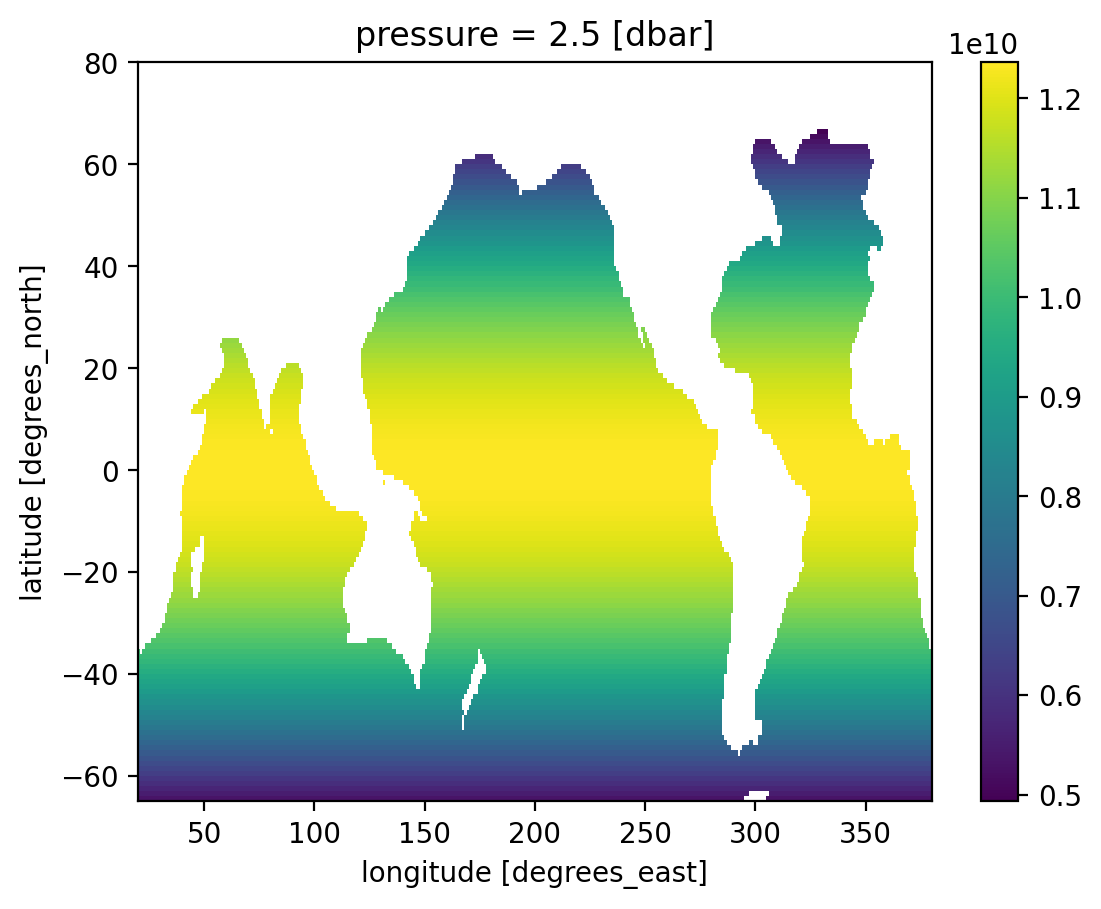

In [9]:
areamasked = (areacella_xarray*Mask)
areamasked.plot()

### Compute weighted means

In [10]:
## define area and depth weights 
areaweights = areamasked
z_weights = thkness

T_z_weighted = (Temperature_ts*Mask).weighted(z_weights)
T_z = T_z_weighted.mean(dim=['pressure'])

T_z_areaweighted = T_z.weighted(areaweights.fillna(0))
T_global_weighted = T_z_areaweighted.mean(dim=['latitude','longitude'])

### This matches the plot shown at https://sio-argo.ucsd.edu/RG_Climatology.html

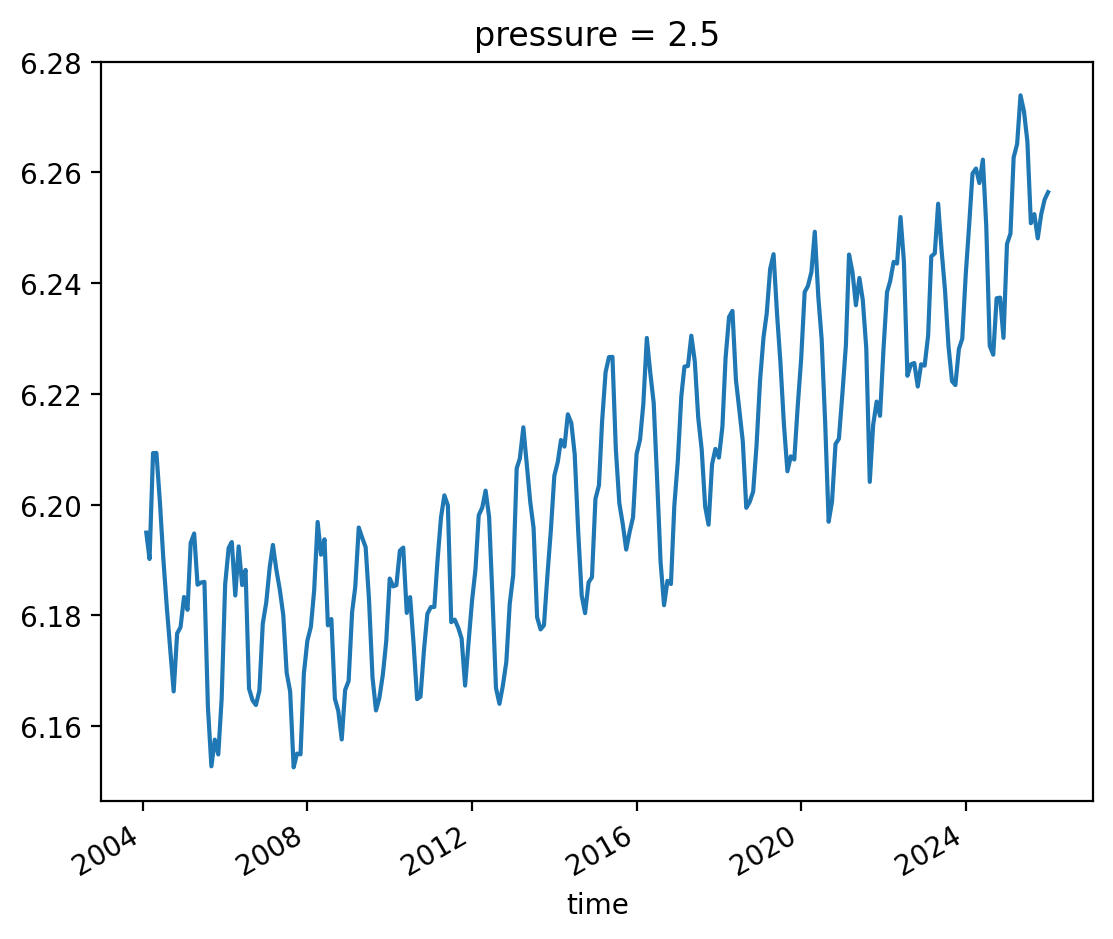

In [11]:
T_global_weighted.plot()

### Compute Potential Density referenced to the surface, which we will use to compute Mixed Layer Depth defined with a 0.03 Kg m-3 criteria. For our potential density calculation we use the momlevel package, employing the Wright EOS and using potential temperature and practical salinity as inputs: https://momlevel.readthedocs.io/en/v0.0.6/api/momlevel.derived.html?highlight=ml.derived#module-momlevel.derived

In [25]:
## Compute potential density referenced to the surface (0)
potential_density_ts = ml.derived.calc_pdens(Temperature_ts, 
                                             Salinity_ts, 
                                             0, 
                                             eos='Wright')

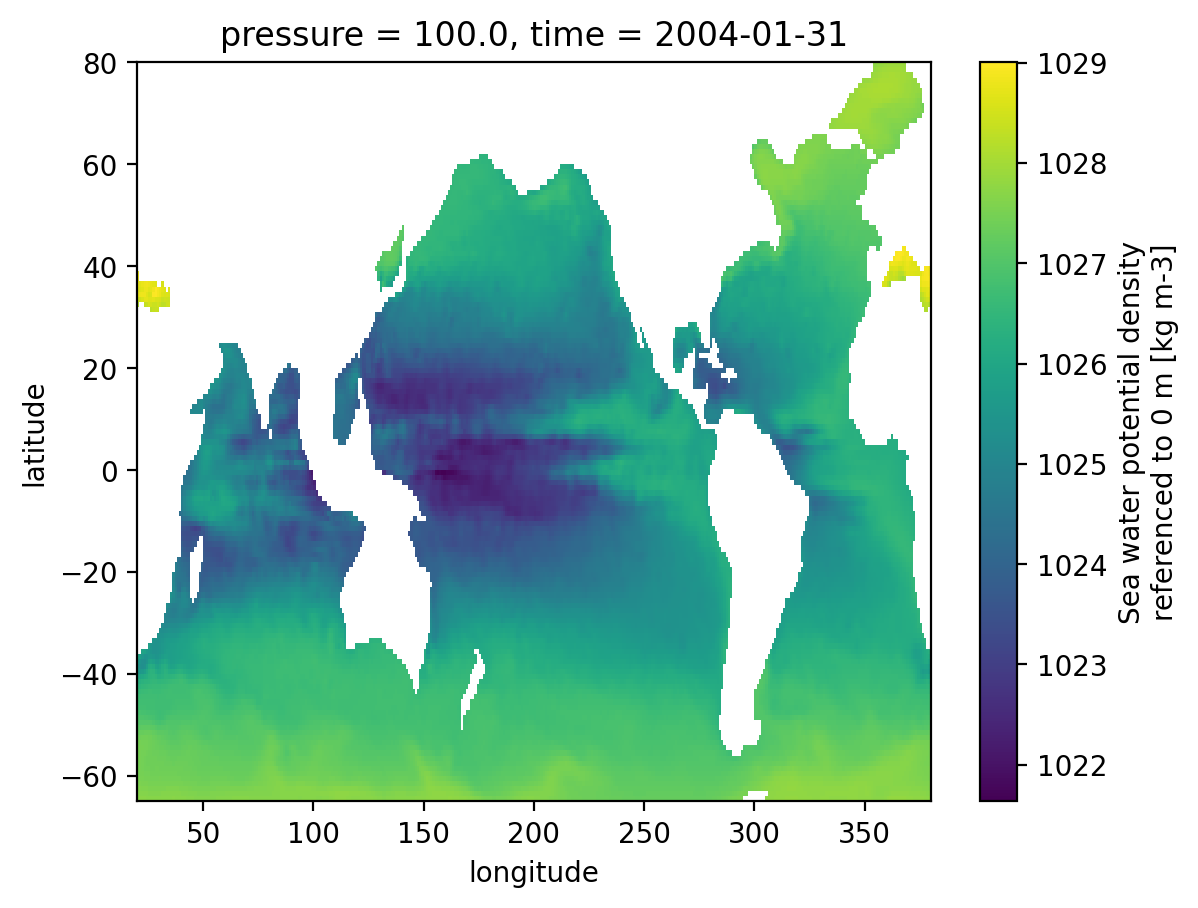

In [26]:
potential_density_ts.isel(time=0,pressure=10).plot()

### Following the de Boyer Montegut et al. (2004) threshold method, MLD is defined as the depth at which potential density changes by the threshold value of 0.03 kg m−3 relative to the 10-m surface reference value. 

##### Here we first compute a time series (for all grid cells) of potential density minus potential density at 10 m (~ 10db), which is index 1 in our dataset (isel(pressure=1)). We then evaluate where this new data array has values LESS THAN 0.03 (<0.03). All the potential density values from the surface to the deepest level where this computed difference is less than 0.03 are retained. These are the values within the mixed layer for every location. We create a "mixed layer mask" where values that are equal to 1 are in the mixed layer and everything else is NaN. (mixed_layer / mixed_layer). We must set index 0 and 1 of this new array to 1 for inclusion the mask, so we do not have 0 / 0.

##### To isolate the temperature, salinity, and potential density values only within the mixed layer we then multiply our T and S fields by our newly created mixed_layer_mask.

In [29]:
## Compute difference relative to 10 m reference value. 10 db ~ 10 m, this is pressure
## index of 1 in this dataset, index 0 is 2.5 db.
drho_relative_to_surface = potential_density_ts - potential_density_ts.isel(pressure=1)
mixed_layer = drho_relative_to_surface.where(drho_relative_to_surface<0.03)
mixed_layer_mask = mixed_layer/mixed_layer
mixed_layer_mask[0] = 1
mixed_layer_mask[1] = 1

## Multiply the property data arrays by the mixed_layer mask created above. This will
Mixed_Layer_T = mixed_layer_mask*Temperature_ts
Mixed_Layer_S = mixed_layer_mask*Salinity_ts
Mixed_Layer_Rho = mixed_layer_mask*potential_density_ts

### Check to make sure this is doing what we want:

In [30]:
Mixed_Layer_T.isel(time=100).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').values                                                                                                          

array([16.16 , 16.16 , 16.155, 16.149, 16.152, 16.16 , 16.174, 16.012,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan], dtype=float32)

### Create a time series of MLD by finding the deepest pressure value at each grid point (lat,lon,time) in our newly created mixed_layer_mask that is NOT a NaN.

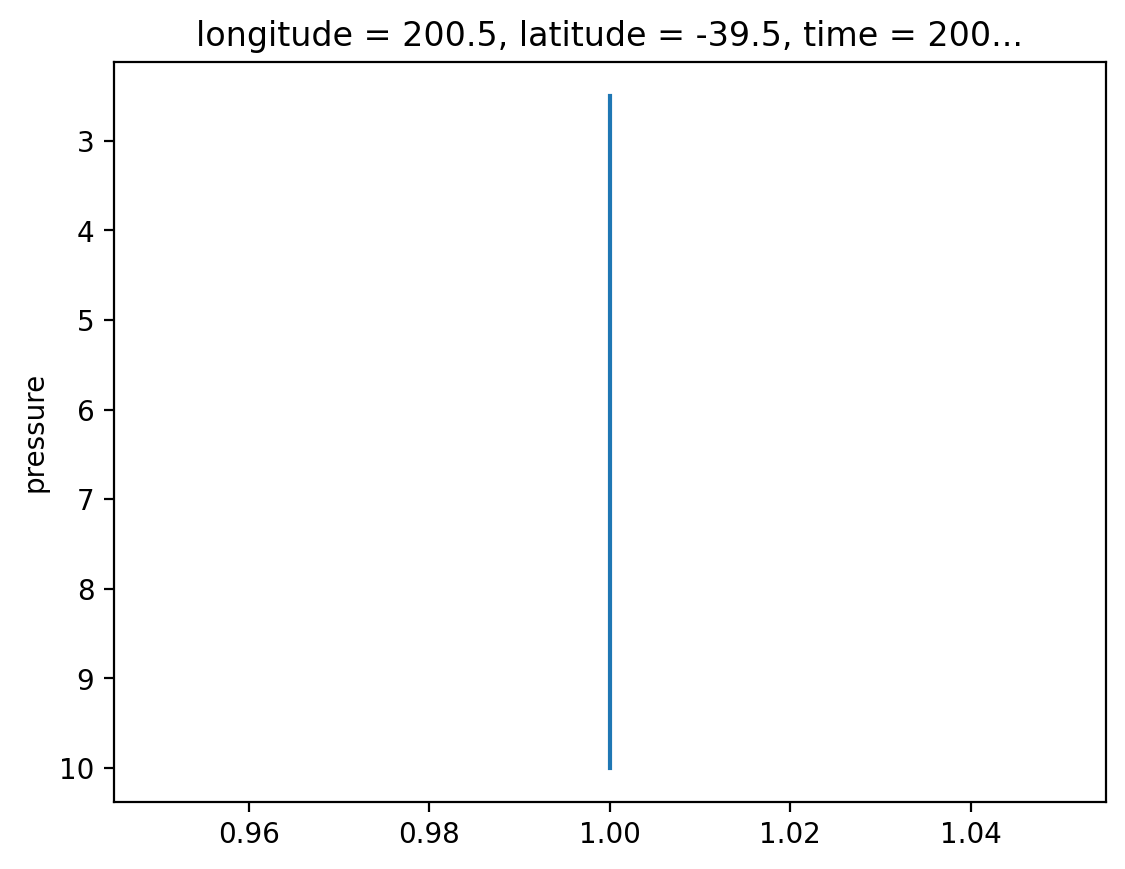

In [31]:
mixed_layer_mask.isel(time=0).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').plot(y='pressure',yincrease=False)

In [32]:
pressure_levels_in_mixed_layer = mixed_layer_mask*mixed_layer_mask.pressure
pressure_max_ml = pressure_levels_in_mixed_layer.max(dim='pressure', skipna=True)
mld = pressure_max_ml

### Check to make sure this is doing what we want:

array(70., dtype=float32)

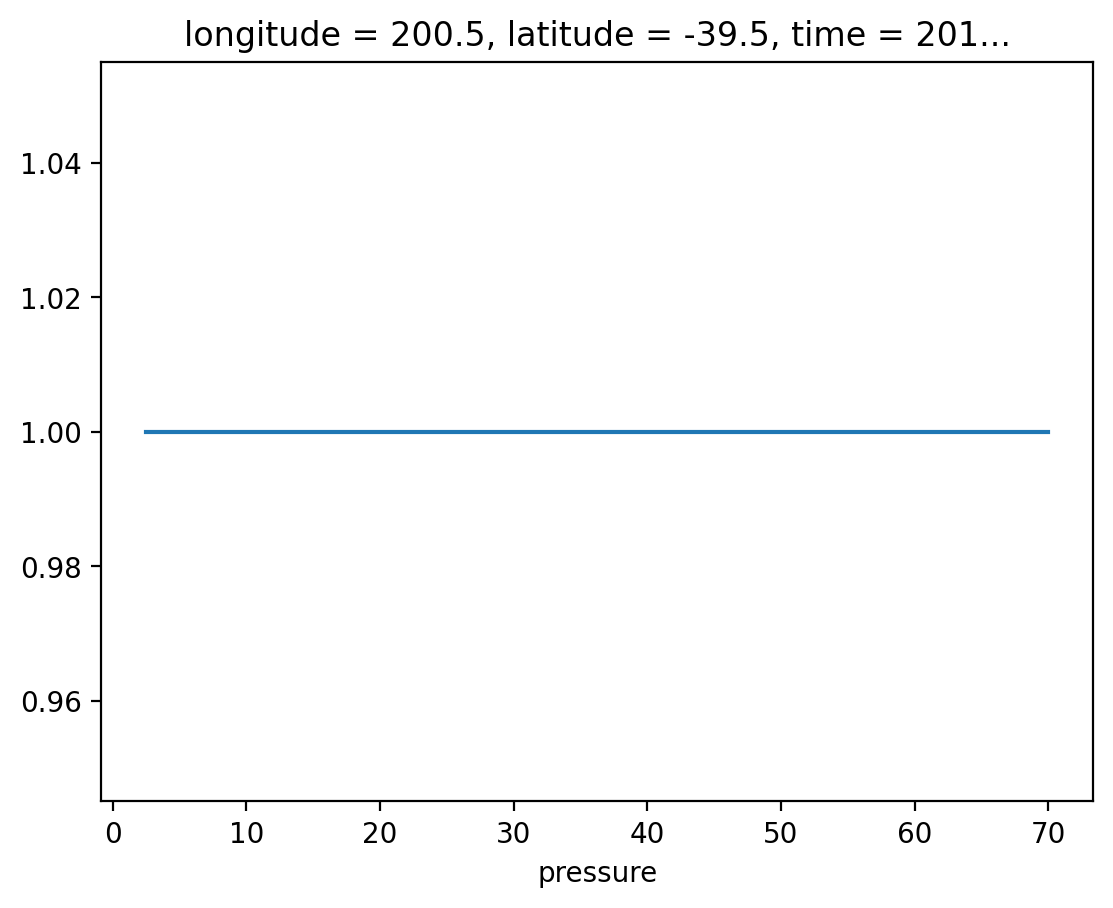

In [33]:
mixed_layer_mask.isel(time=100).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').plot()
mld.isel(time=100).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').values

### Compute depth-averaged (weighted) mixed layer T, S, potential density fields and save out these fields as well as the non-depth averaged fields as netcdf files for the simplicity of future analysis.

In [34]:
z_ml_weights = thkness*mixed_layer_mask  ## create field of thkness that only exists within the mixed layer
MLT_z_weighted = (Mixed_Layer_T).weighted(z_ml_weights.fillna(0))
MLT_z_weighted_ave = MLT_z_weighted.mean(dim='pressure')

MLS_z_weighted = (Mixed_Layer_S).weighted(z_ml_weights.fillna(0))
MLS_z_weighted_ave = MLS_z_weighted.mean(dim='pressure')

MLpotoRho_z_weighted = (Mixed_Layer_Rho).weighted(z_ml_weights.fillna(0))
MLpotoRho_z_weighted_ave = MLpotoRho_z_weighted.mean(dim='pressure')

In [35]:
RG_MixedLayer_Properties = xr.Dataset()

RG_MixedLayer_Properties['MLT_depth_ave'] =  MLT_z_weighted_ave
RG_MixedLayer_Properties['MLS_depth_ave'] =  MLS_z_weighted_ave
RG_MixedLayer_Properties['MLpotoRho_depth_ave'] =  MLpotoRho_z_weighted_ave

RG_MixedLayer_Properties['MLT'] =  Mixed_Layer_T
RG_MixedLayer_Properties['MLS'] =  Mixed_Layer_S
RG_MixedLayer_Properties['MLpotoRho'] =  Mixed_Layer_Rho

RG_MixedLayer_Properties['MLD'] =  mld

In [36]:
RG_MixedLayer_Properties

<xarray.Dataset>
Dimensions:              (longitude: 360, latitude: 145, time: 264, pressure: 58)
Coordinates:
  * longitude            (longitude) float32 20.5 21.5 22.5 ... 378.5 379.5
  * latitude             (latitude) float32 -64.5 -63.5 -62.5 ... 77.5 78.5 79.5
  * time                 (time) datetime64[ns] 2004-01-31 ... 2025-12-31
  * pressure             (pressure) float32 2.5 10.0 20.0 ... 1.9e+03 1.975e+03
Data variables:
    MLT_depth_ave        (latitude, longitude, time) float32 -0.06167 ... nan
    MLS_depth_ave        (latitude, longitude, time) float32 33.76 33.83 ... nan
    MLpotoRho_depth_ave  (latitude, longitude, time) float32 1.027e+03 ... nan
    MLT                  (pressure, latitude, longitude, time) float32 -0.033...
    MLS                  (pressure, latitude, longitude, time) float32 33.75 ...
    MLpotoRho            (pressure, latitude, longitude, time) float32 1.027e...
    MLD                  (latitude, longitude, time) float32 10.0 20.0 ... 10.0

In [37]:
RG_MixedLayer_Properties.to_netcdf('RG_MixedLayer_Properties_2004_to_Jan2004_Dec2025.nc')

In [38]:
RG_MixedLayerProperties = xr.open_dataset('RG_MixedLayer_Properties_2004_to_Jan2004_Dec2025.nc')

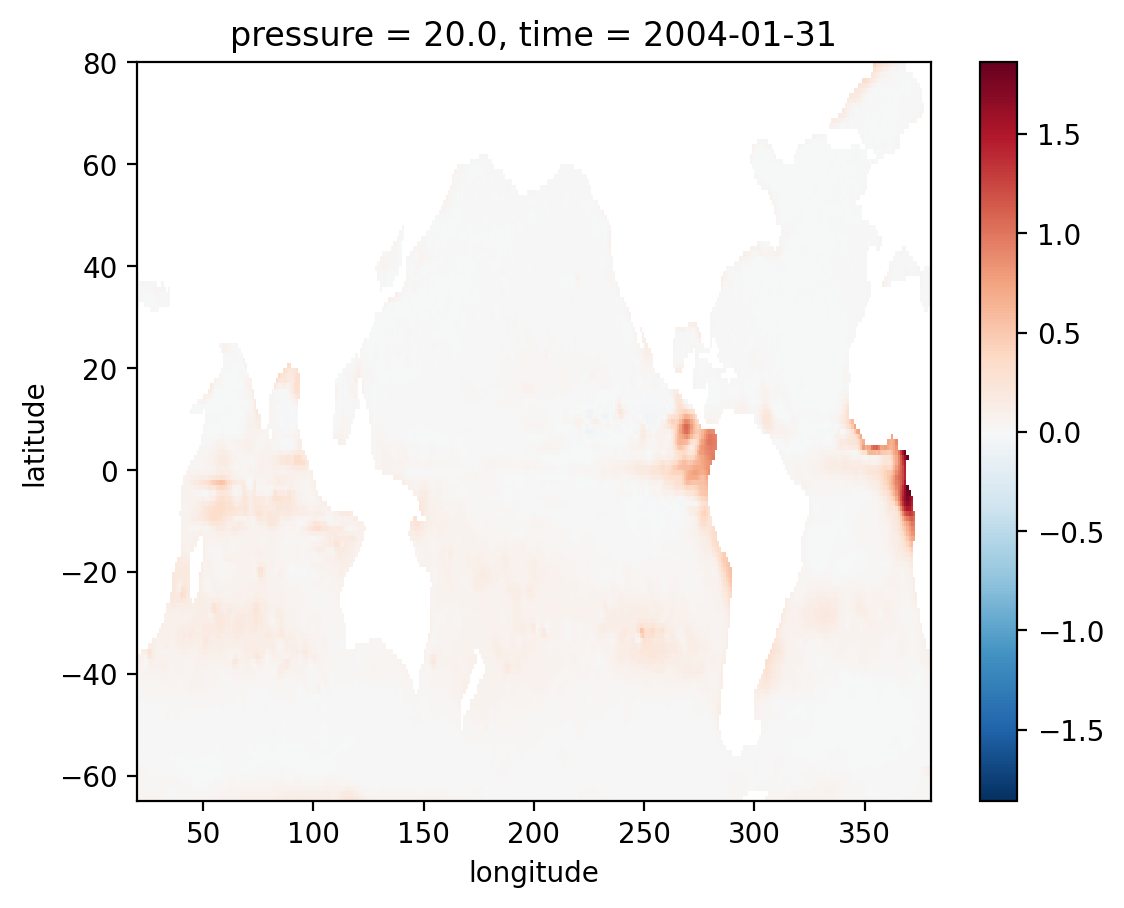

In [40]:
drho_relative_to_surface.isel(time=0,pressure=2).plot()

In [41]:
drho_relative_to_surface.isel(time=201).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').values

array([-0.00415039,  0.        ,  0.00671387,  0.01538086,  0.02587891,
        0.04052734,  0.05407715,  0.06677246,  0.08288574,  0.10510254,
        0.125     ,  0.15112305,  0.17834473,  0.21643066,  0.2713623 ,
        0.321167  ,  0.3774414 ,  0.42504883,  0.4736328 ,  0.53881836,
        0.600708  ,  0.6447754 ,  0.677124  ,  0.7011719 ,  0.7199707 ,
        0.73620605,  0.7503662 ,  0.76220703,  0.77124023,  0.7796631 ,
        0.7871094 ,  0.7937012 ,  0.8009033 ,  0.8117676 ,  0.8267822 ,
        0.84191895,  0.85717773,  0.8736572 ,  0.8935547 ,  0.9182129 ,
        0.9448242 ,  0.9769287 ,  1.0134277 ,  1.0522461 ,  1.0921631 ,
        1.1311035 ,  1.1660156 ,  1.2000732 ,  1.2352295 ,  1.2677002 ,
        1.3015137 ,  1.3393555 ,  1.3883057 ,  1.4387207 ,  1.477417  ,
        1.5056152 ,  1.5297852 ,  1.5443115 ], dtype=float32)

In [42]:
Mixed_Layer_T.isel(time=5).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').values                                                                                                          

array([14.924999, 14.926   , 14.924   , 14.921   , 14.917999, 14.876   ,
       14.833   , 14.771   ,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan], dtype=float32)

### Compute mixed-layer averaged T, S, rho:

In [27]:
z_ml_weights = thkness*mixed_layer_mask
MLT_z_weighted = (Mixed_Layer_T).weighted(z_ml_weights.fillna(0))
MLT_z_weighted_ave = MLT_z_weighted.mean(dim='pressure')

MLS_z_weighted = (Mixed_Layer_S).weighted(z_ml_weights.fillna(0))
MLS_z_weighted_ave = MLS_z_weighted.mean(dim='pressure')

MLpotoRho_z_weighted = (Mixed_Layer_Rho).weighted(z_ml_weights.fillna(0))
MLpotoRho_z_weighted_ave = MLpotoRho_z_weighted.mean(dim='pressure')

### Produce plots of mixed layer salinity and temperature to compare to BAM's 2021 report anomalies

In [28]:
#### BAMS 2021 Anomalies

MLT_2004_2020 = MLT_z_weighted_ave.sel(time=slice('2004-01-31','2020-12-31')).mean(dim='time')
MLT_2021 = MLT_z_weighted_ave.sel(time=slice('2021-01-31','2021-12-31')).mean(dim='time')
MLT_2021_report_diff = MLT_2021 - MLT_2004_2020

MLS_2004_2020 = MLS_z_weighted_ave.sel(time=slice('2004-01-31','2020-12-31')).mean(dim='time')
MLS_2021 = MLS_z_weighted_ave.sel(time=slice('2021-01-31','2021-12-31')).mean(dim='time')
MLS_2021_report_diff = MLS_2021 - MLS_2004_2020

#### BAMS 2022 Anomalies
MLT_2004_2021 = MLT_z_weighted_ave.sel(time=slice('2004-01-31','2021-12-31')).mean(dim='time')
MLT_2022 = MLT_z_weighted_ave.sel(time=slice('2022-01-31','2022-10-31')).mean(dim='time')
MLT_2022_report_diff = MLT_2022 - MLT_2004_2021

MLS_2004_2021 = MLS_z_weighted_ave.sel(time=slice('2004-01-31','2021-12-31')).mean(dim='time')
MLS_2022 = MLS_z_weighted_ave.sel(time=slice('2022-01-31','2022-10-31')).mean(dim='time')
MLS_2022_report_diff = MLS_2022 - MLS_2004_2021

#### Compute 2022 - 2021:
MLS_2022_minus_2021 = MLS_2022 - MLS_2021
MLT_2022_minus_2021 = MLT_2022 - MLT_2021

### Polar Projection

In [29]:
import matplotlib.path as mpath

## Function to set up Antarctic polar projection:
### Antarctic map for plotting:
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

import matplotlib.ticker as mticker

def antarctic_map(ax, grid):
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.set_extent([-180, 180, -90, -55], ccrs.PlateCarree())
    if grid == True:
        gl = ax.gridlines(linewidth = 1, color = 'grey', linestyle = '--')
        gl.ylocator = mticker.FixedLocator([-90, -80, -70, -60, -50])

Text(0.5, 1.0, '2022 MLS Anomalies')

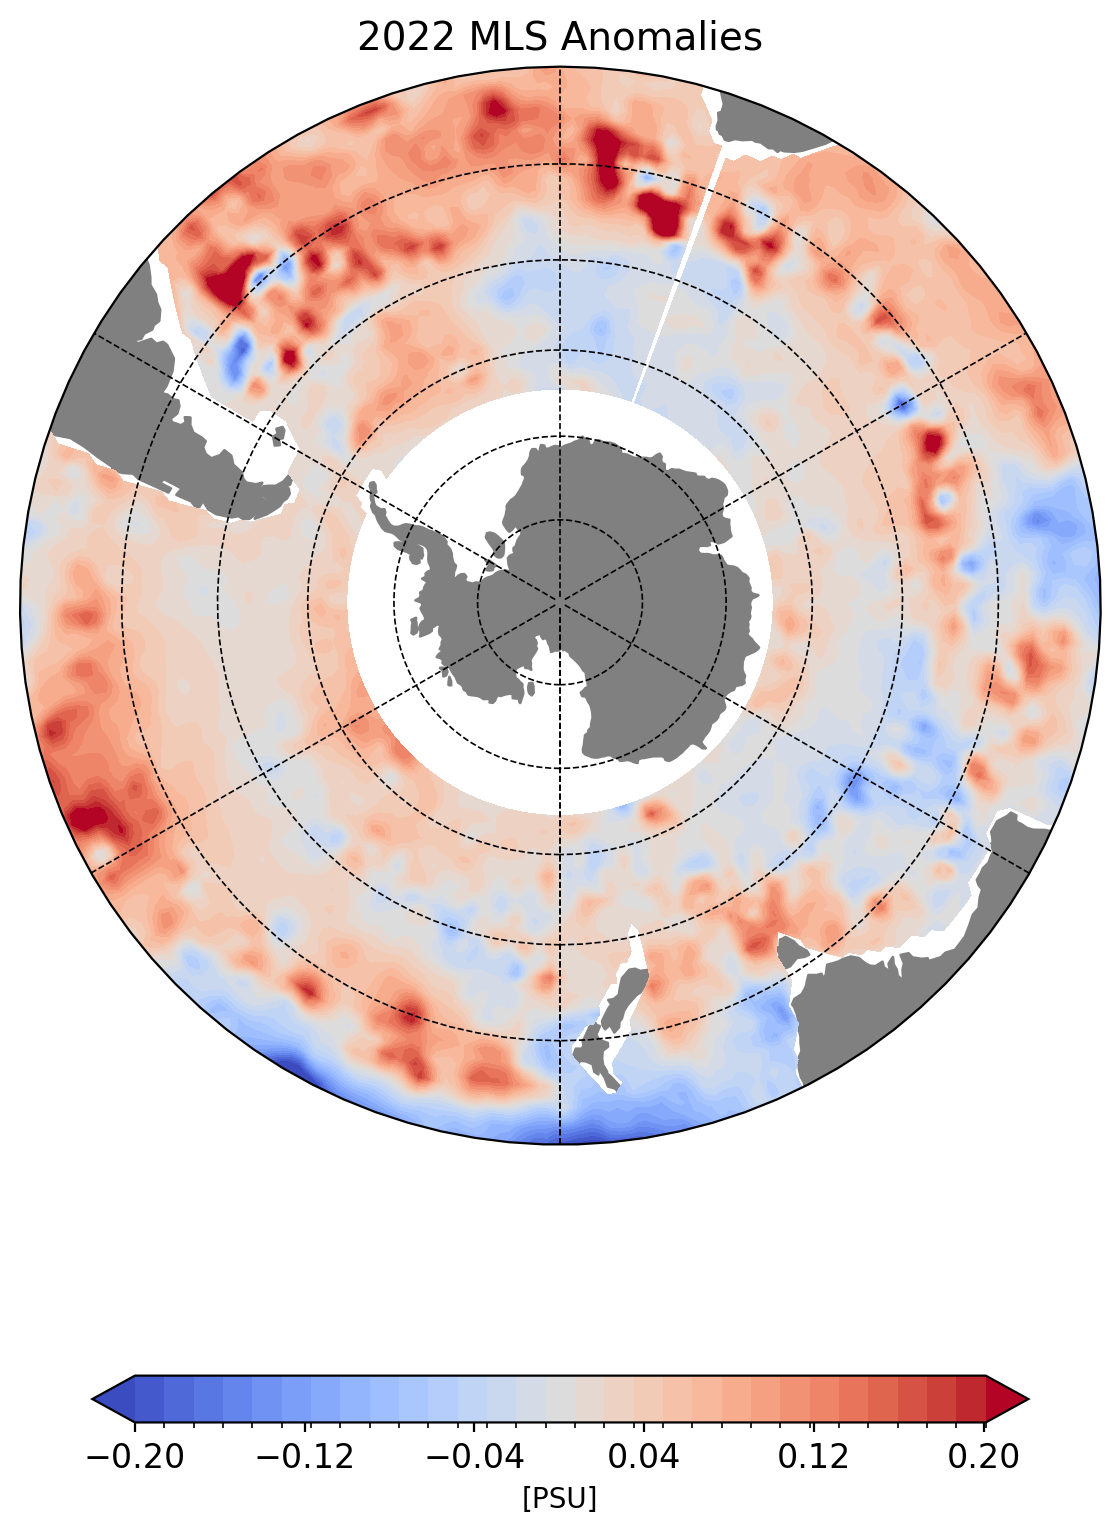

In [30]:
import cartopy.crs as ccrs
import cartopy

plt.figure(figsize=[12,8])

projection=ccrs.SouthPolarStereo()
ax = plt.axes(projection=projection)
ax.set_extent([-180,180,-90,-30], ccrs.PlateCarree())
ax.set_boundary(circle,transform=ax.transAxes)

MLS_levels = np.linspace(-0.2,0.201,30)

p = MLS_2022_report_diff.plot.contourf(
                        cmap='coolwarm',
                        transform=ccrs.PlateCarree(),
                        levels=MLS_levels,add_colorbar=False)

ax.gridlines(linewidth = 0.6, color = 'k', linestyle = '--')
ax.add_feature(cartopy.feature.LAND, color='grey')
cb = plt.colorbar(p, ticks=[-0.2,-0.12,-0.04,0.04,0.12,0.2],
                  extend='both',
                  shrink=0.4,
                  orientation='horizontal')

cb.ax.tick_params(labelsize=12)
plt.tight_layout()
cb.set_label('[PSU]')
plt.title('2022 MLS Anomalies',fontsize=14)

Text(0.5, 1.0, '2021 MLS Anomalies')

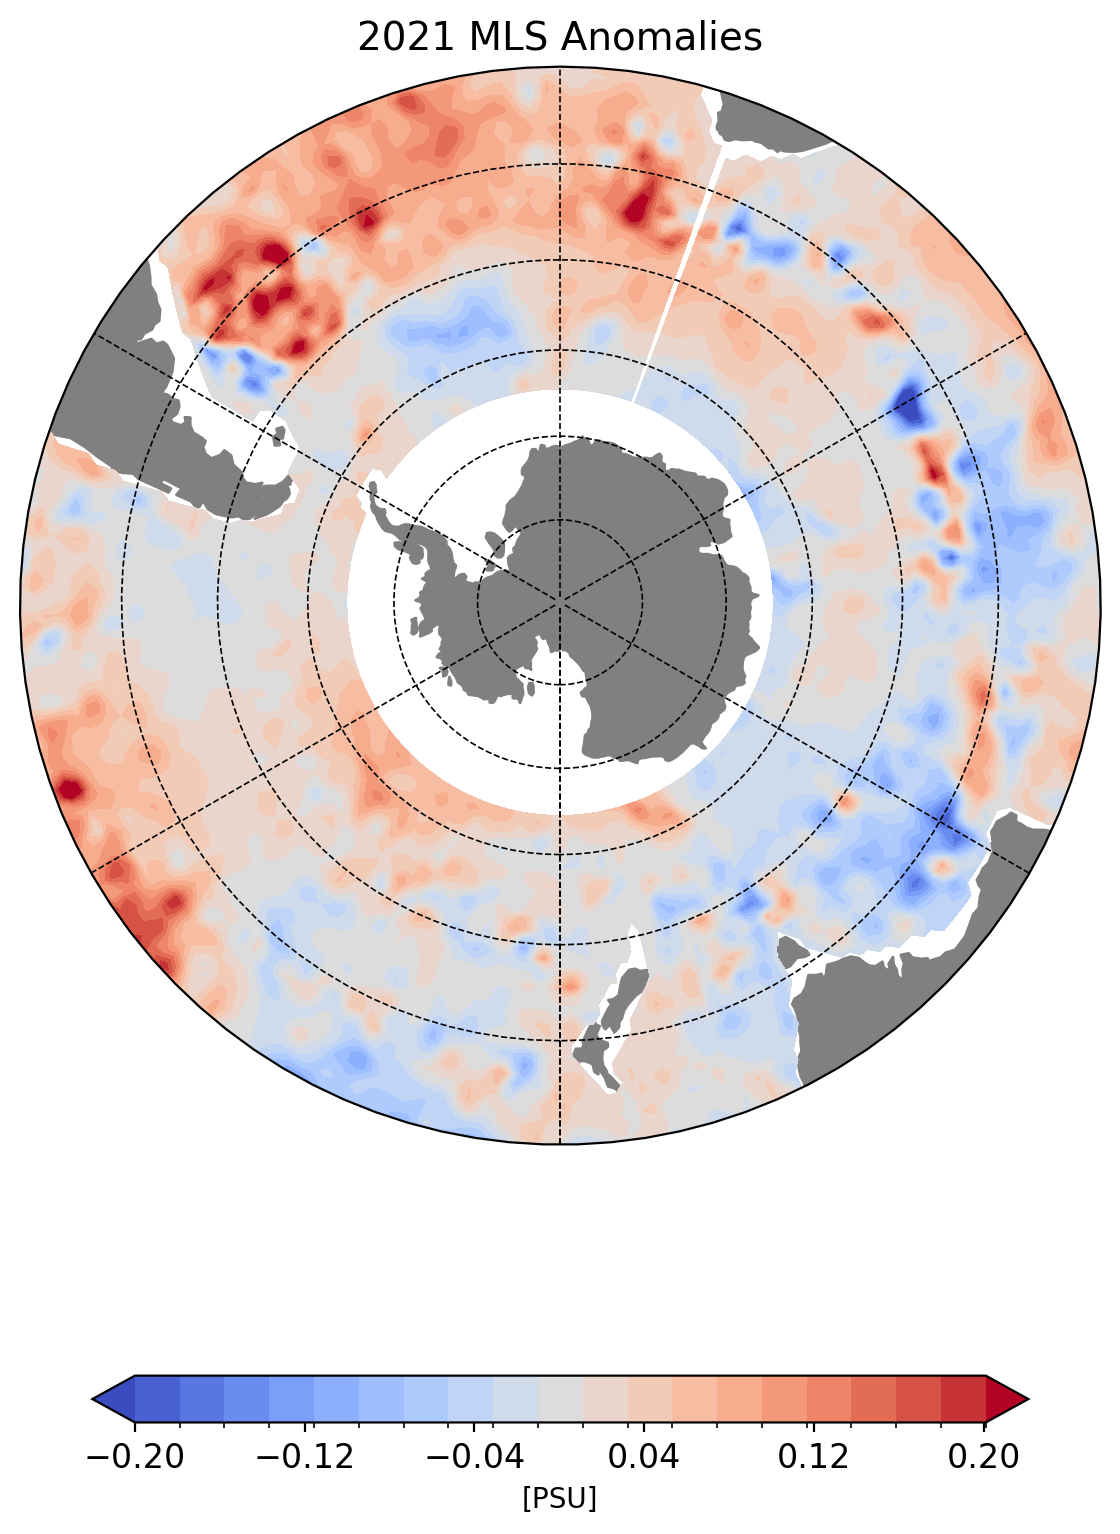

In [31]:
import cartopy.crs as ccrs
import cartopy

plt.figure(figsize=[12,8])

projection=ccrs.SouthPolarStereo()
ax = plt.axes(projection=projection)
ax.set_extent([-180,180,-90,-30], ccrs.PlateCarree())
ax.set_boundary(circle,transform=ax.transAxes)

MLS_levels = np.linspace(-0.2,0.201,20)

p = MLS_2021_report_diff.plot.contourf(
                        cmap='coolwarm',
                        transform=ccrs.PlateCarree(),
                        levels=MLS_levels,add_colorbar=False)

ax.gridlines(linewidth = 0.6, color = 'k', linestyle = '--')
ax.add_feature(cartopy.feature.LAND, color='grey')
cb = plt.colorbar(p, ticks=[-0.2,-0.12,-0.04,0.04,0.12,0.2],
                  extend='both',
                  shrink=0.4,
                  orientation='horizontal')

cb.ax.tick_params(labelsize=12)
plt.tight_layout()
cb.set_label('[PSU]')
plt.title('2021 MLS Anomalies',fontsize=14)

Text(0.5, 1.0, '2022 minus 2021 MLS')

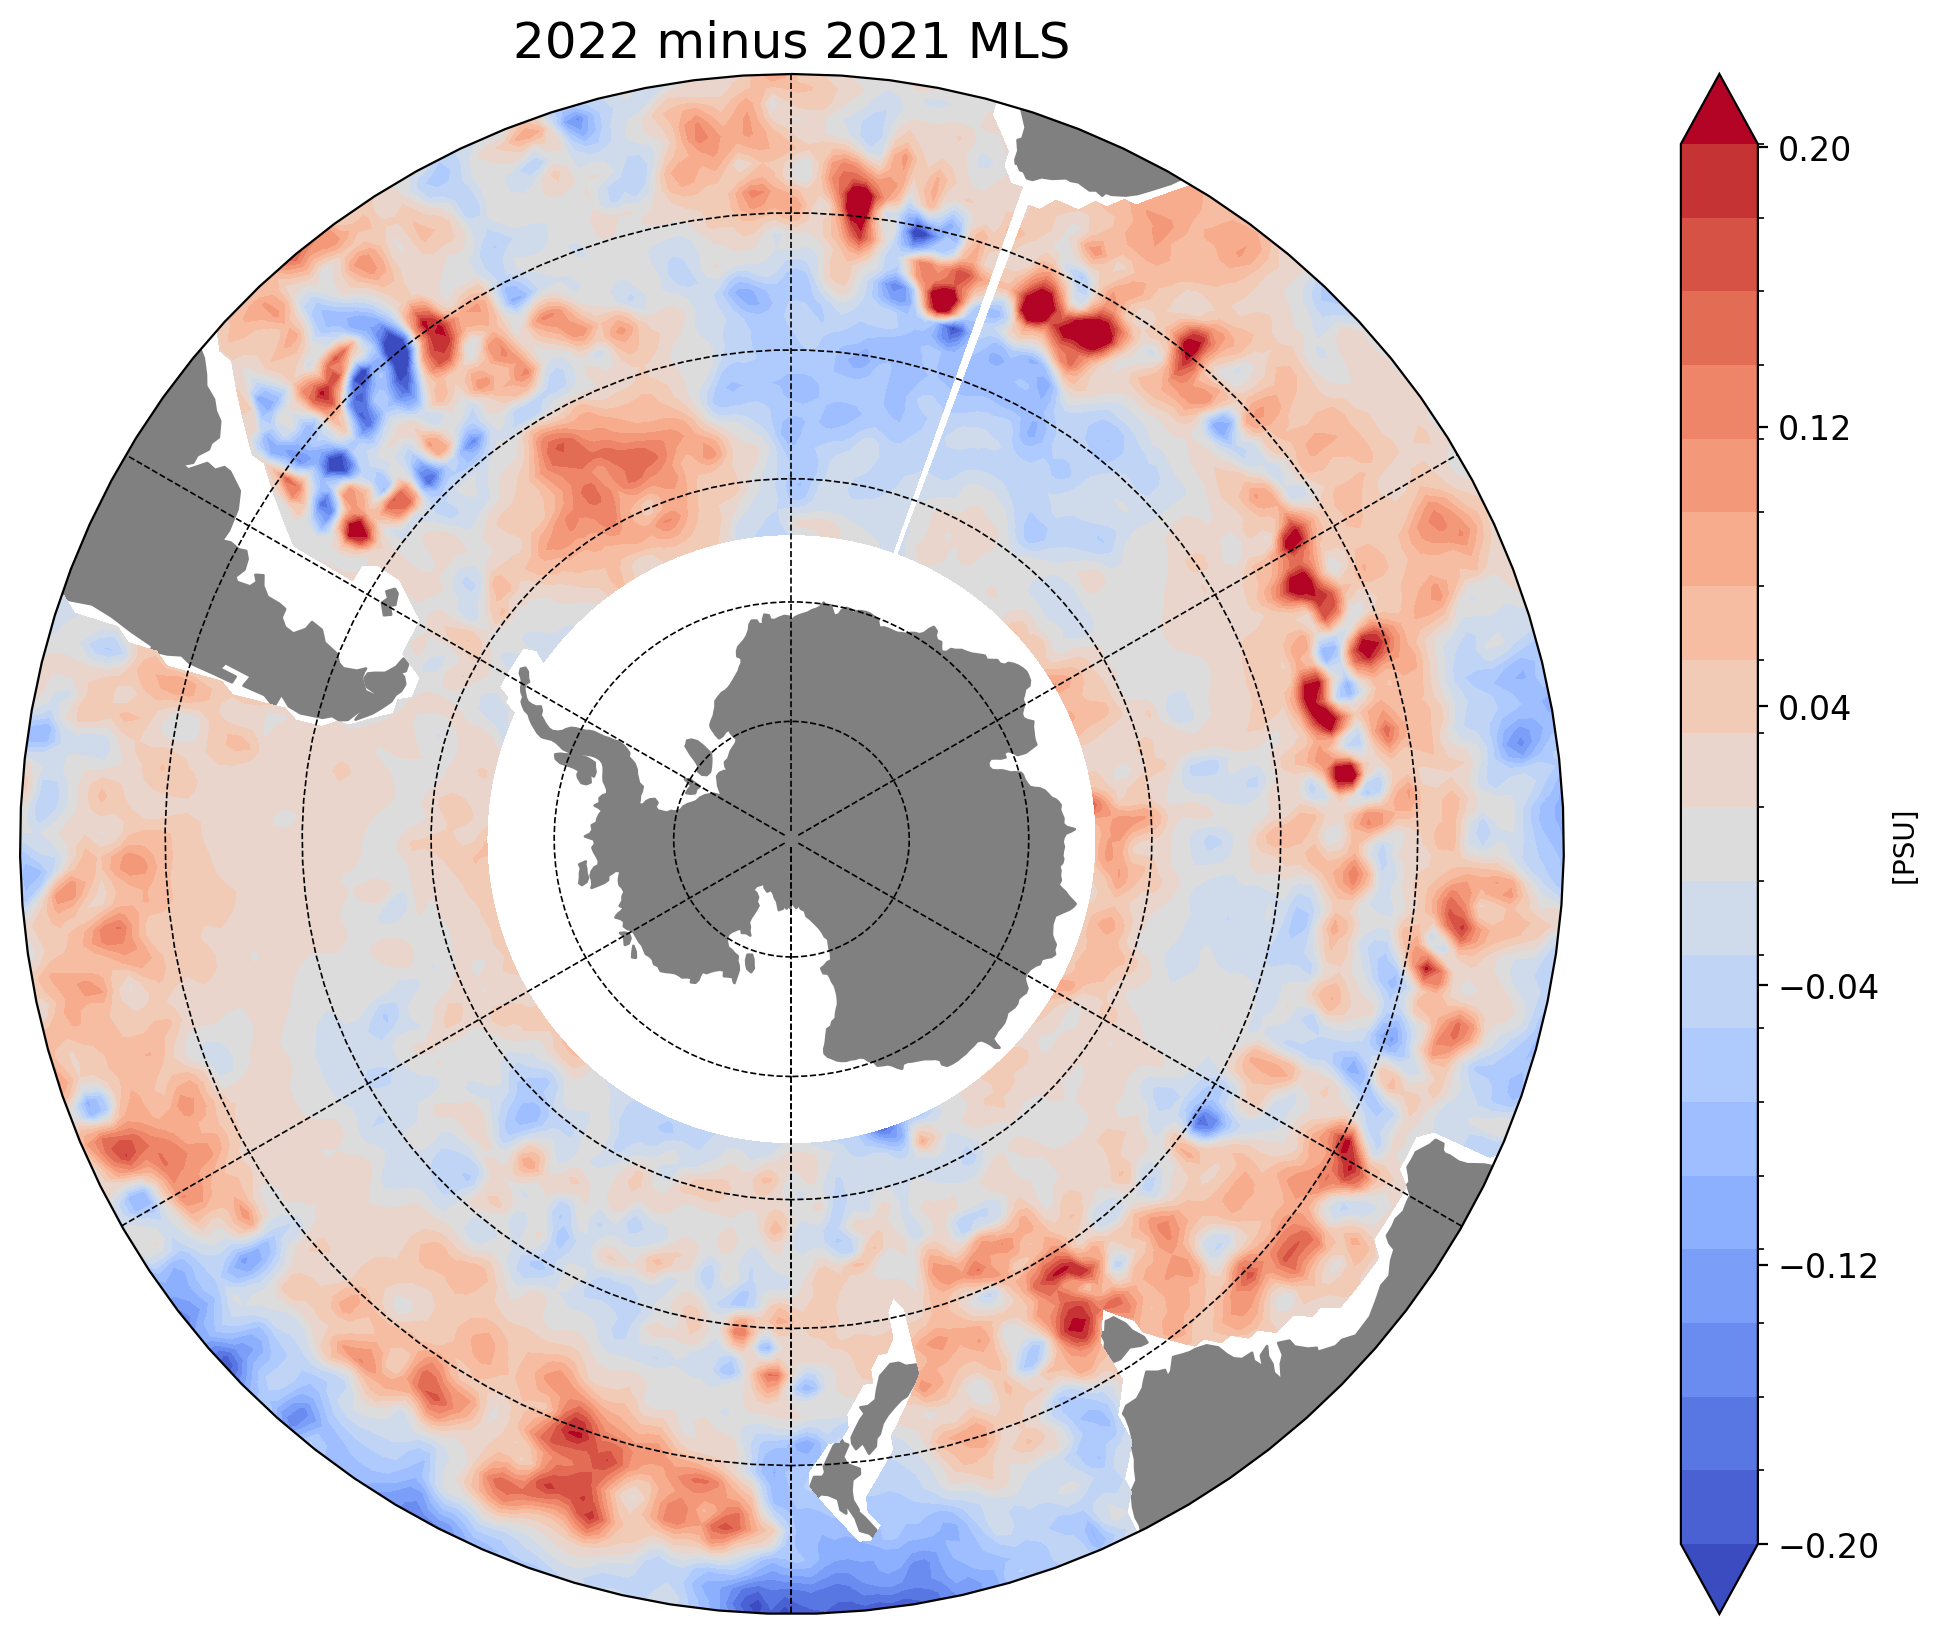

In [32]:
import cartopy.crs as ccrs
import cartopy

plt.figure(figsize=[12,8])

projection=ccrs.SouthPolarStereo()
ax = plt.axes(projection=projection)
ax.set_extent([-180,180,-90,-30], ccrs.PlateCarree())
ax.set_boundary(circle,transform=ax.transAxes)

MLS_levels = np.linspace(-0.2,0.201,20)

p = MLS_2022_minus_2021.plot.contourf(
                        cmap='coolwarm',
                        transform=ccrs.PlateCarree(),
                        levels=MLS_levels,add_colorbar=False)

ax.gridlines(linewidth = 0.6, color = 'k', linestyle = '--')
ax.add_feature(cartopy.feature.LAND, color='grey')
cb = plt.colorbar(p, ticks=[-0.2,-0.12,-0.04,0.04,0.12,0.2],
                  extend='both',
                  
                  )

cb.ax.tick_params(labelsize=12)
plt.tight_layout()
cb.set_label('[PSU]')
plt.title('2022 minus 2021 MLS',fontsize=18)

Text(0.5, 1.0, '2022 MLT Anomalies')

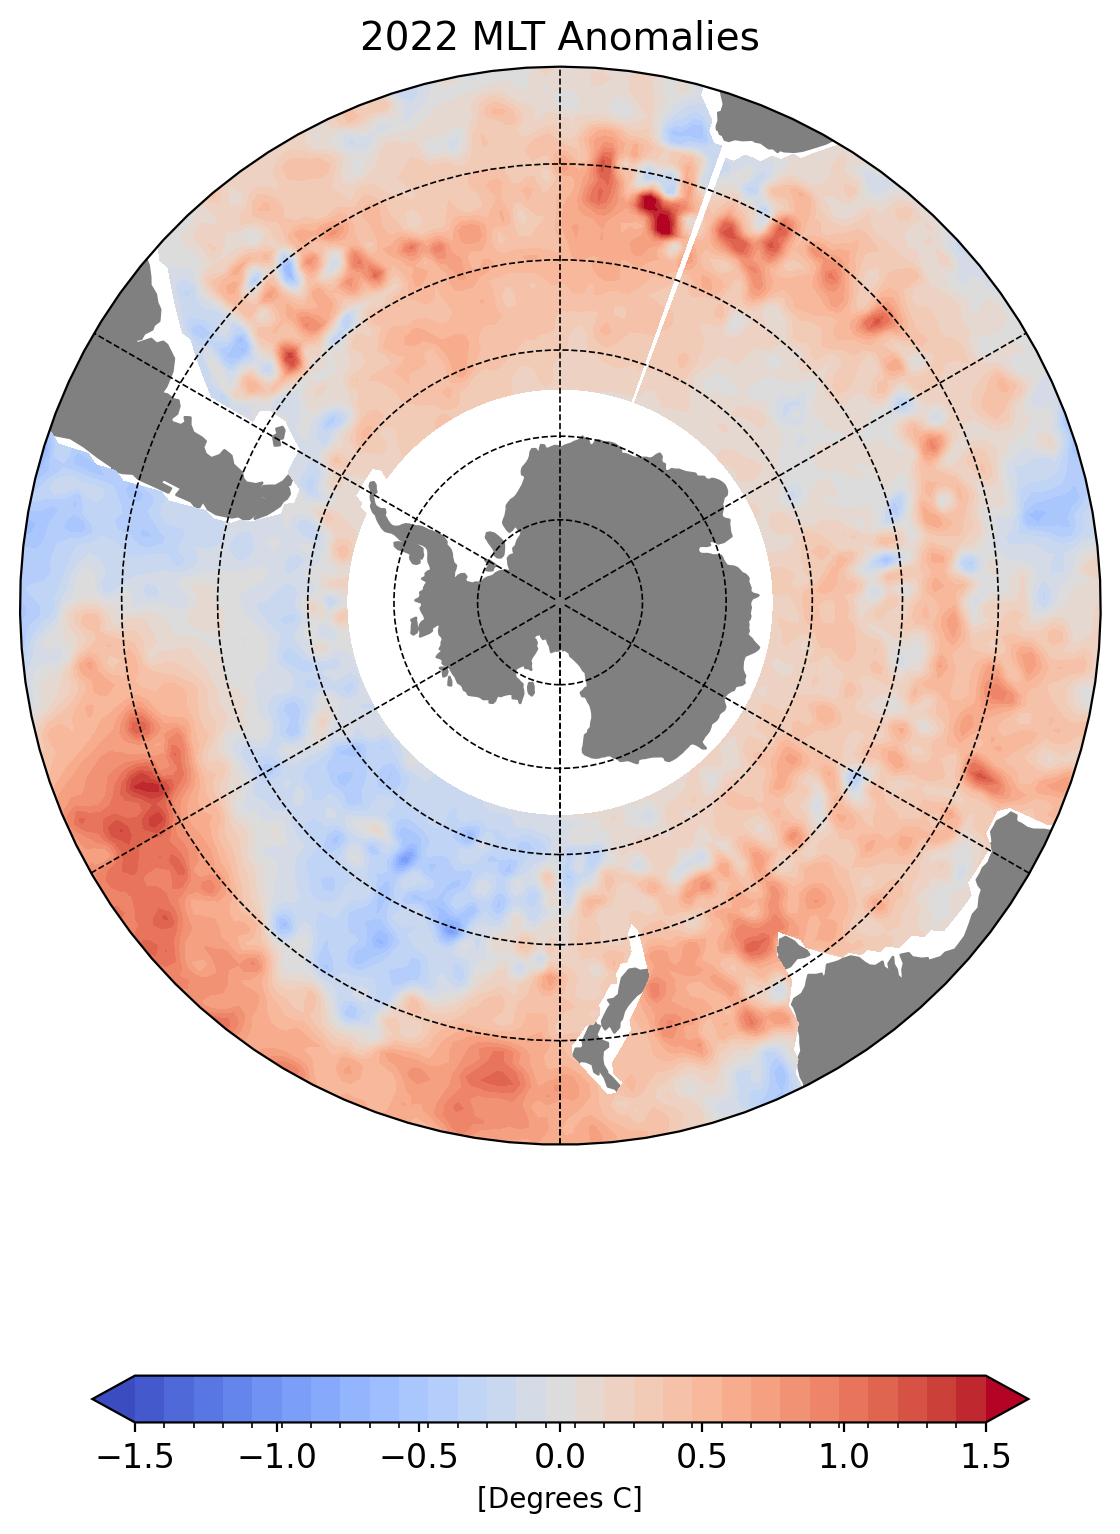

In [33]:
import cartopy.crs as ccrs
import cartopy

plt.figure(figsize=[12,8])

projection=ccrs.SouthPolarStereo()
ax = plt.axes(projection=projection)
ax.set_extent([-180,180,-90,-30], ccrs.PlateCarree())
ax.set_boundary(circle,transform=ax.transAxes)

MLT_levels = np.linspace(-1.5,1.5,30)

p = MLT_2022_report_diff.plot.contourf(
                        cmap='coolwarm',
                        transform=ccrs.PlateCarree(),
                        levels=MLT_levels,add_colorbar=False,extend='both')

ax.gridlines(linewidth = 0.6, color = 'k', linestyle = '--')
ax.add_feature(cartopy.feature.LAND, color='grey')
cb = plt.colorbar(p, ticks=[-1.5,-1.0,-0.5,0,0.5,1.0,1.5],
                  extend='both',
                  shrink=0.4,
                  orientation='horizontal')

cb.ax.tick_params(labelsize=12)
plt.tight_layout()
cb.set_label('[Degrees C]')
plt.title('2022 MLT Anomalies',fontsize=14)

Text(0.5, 1.0, '2021 MLT Anomalies')

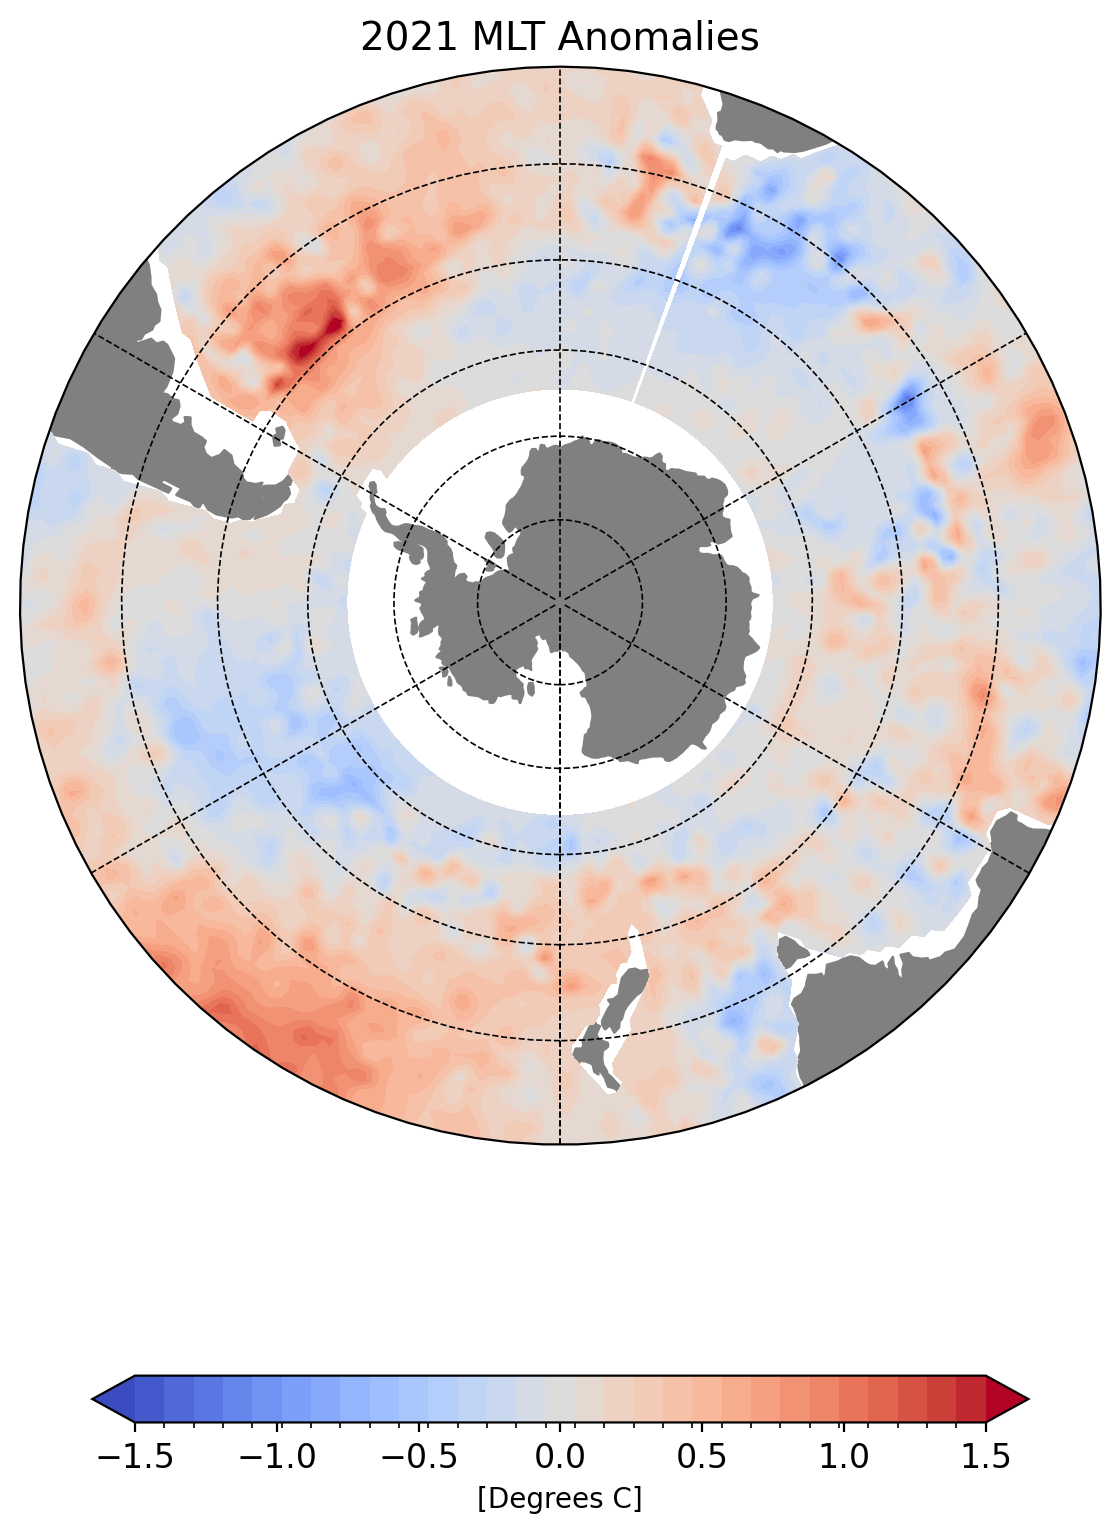

In [34]:
import cartopy.crs as ccrs
import cartopy

plt.figure(figsize=[12,8])

projection=ccrs.SouthPolarStereo()
ax = plt.axes(projection=projection)
ax.set_extent([-180,180,-90,-30], ccrs.PlateCarree())
ax.set_boundary(circle,transform=ax.transAxes)

MLT_levels = np.linspace(-1.5,1.5,30)

p = MLT_2021_report_diff.plot.contourf(
                        cmap='coolwarm',
                        transform=ccrs.PlateCarree(),
                        levels=MLT_levels,add_colorbar=False,extend='both')

ax.gridlines(linewidth = 0.6, color = 'k', linestyle = '--')
ax.add_feature(cartopy.feature.LAND, color='grey')
cb = plt.colorbar(p, ticks=[-1.5,-1.0,-0.5,0,0.5,1.0,1.5],
                  extend='both',
                  shrink=0.4,
                  orientation='horizontal')

cb.ax.tick_params(labelsize=12)
plt.tight_layout()
cb.set_label('[Degrees C]')
plt.title('2021 MLT Anomalies',fontsize=14)

Text(0.5, 1.0, '2022 minus 2021 MLT')

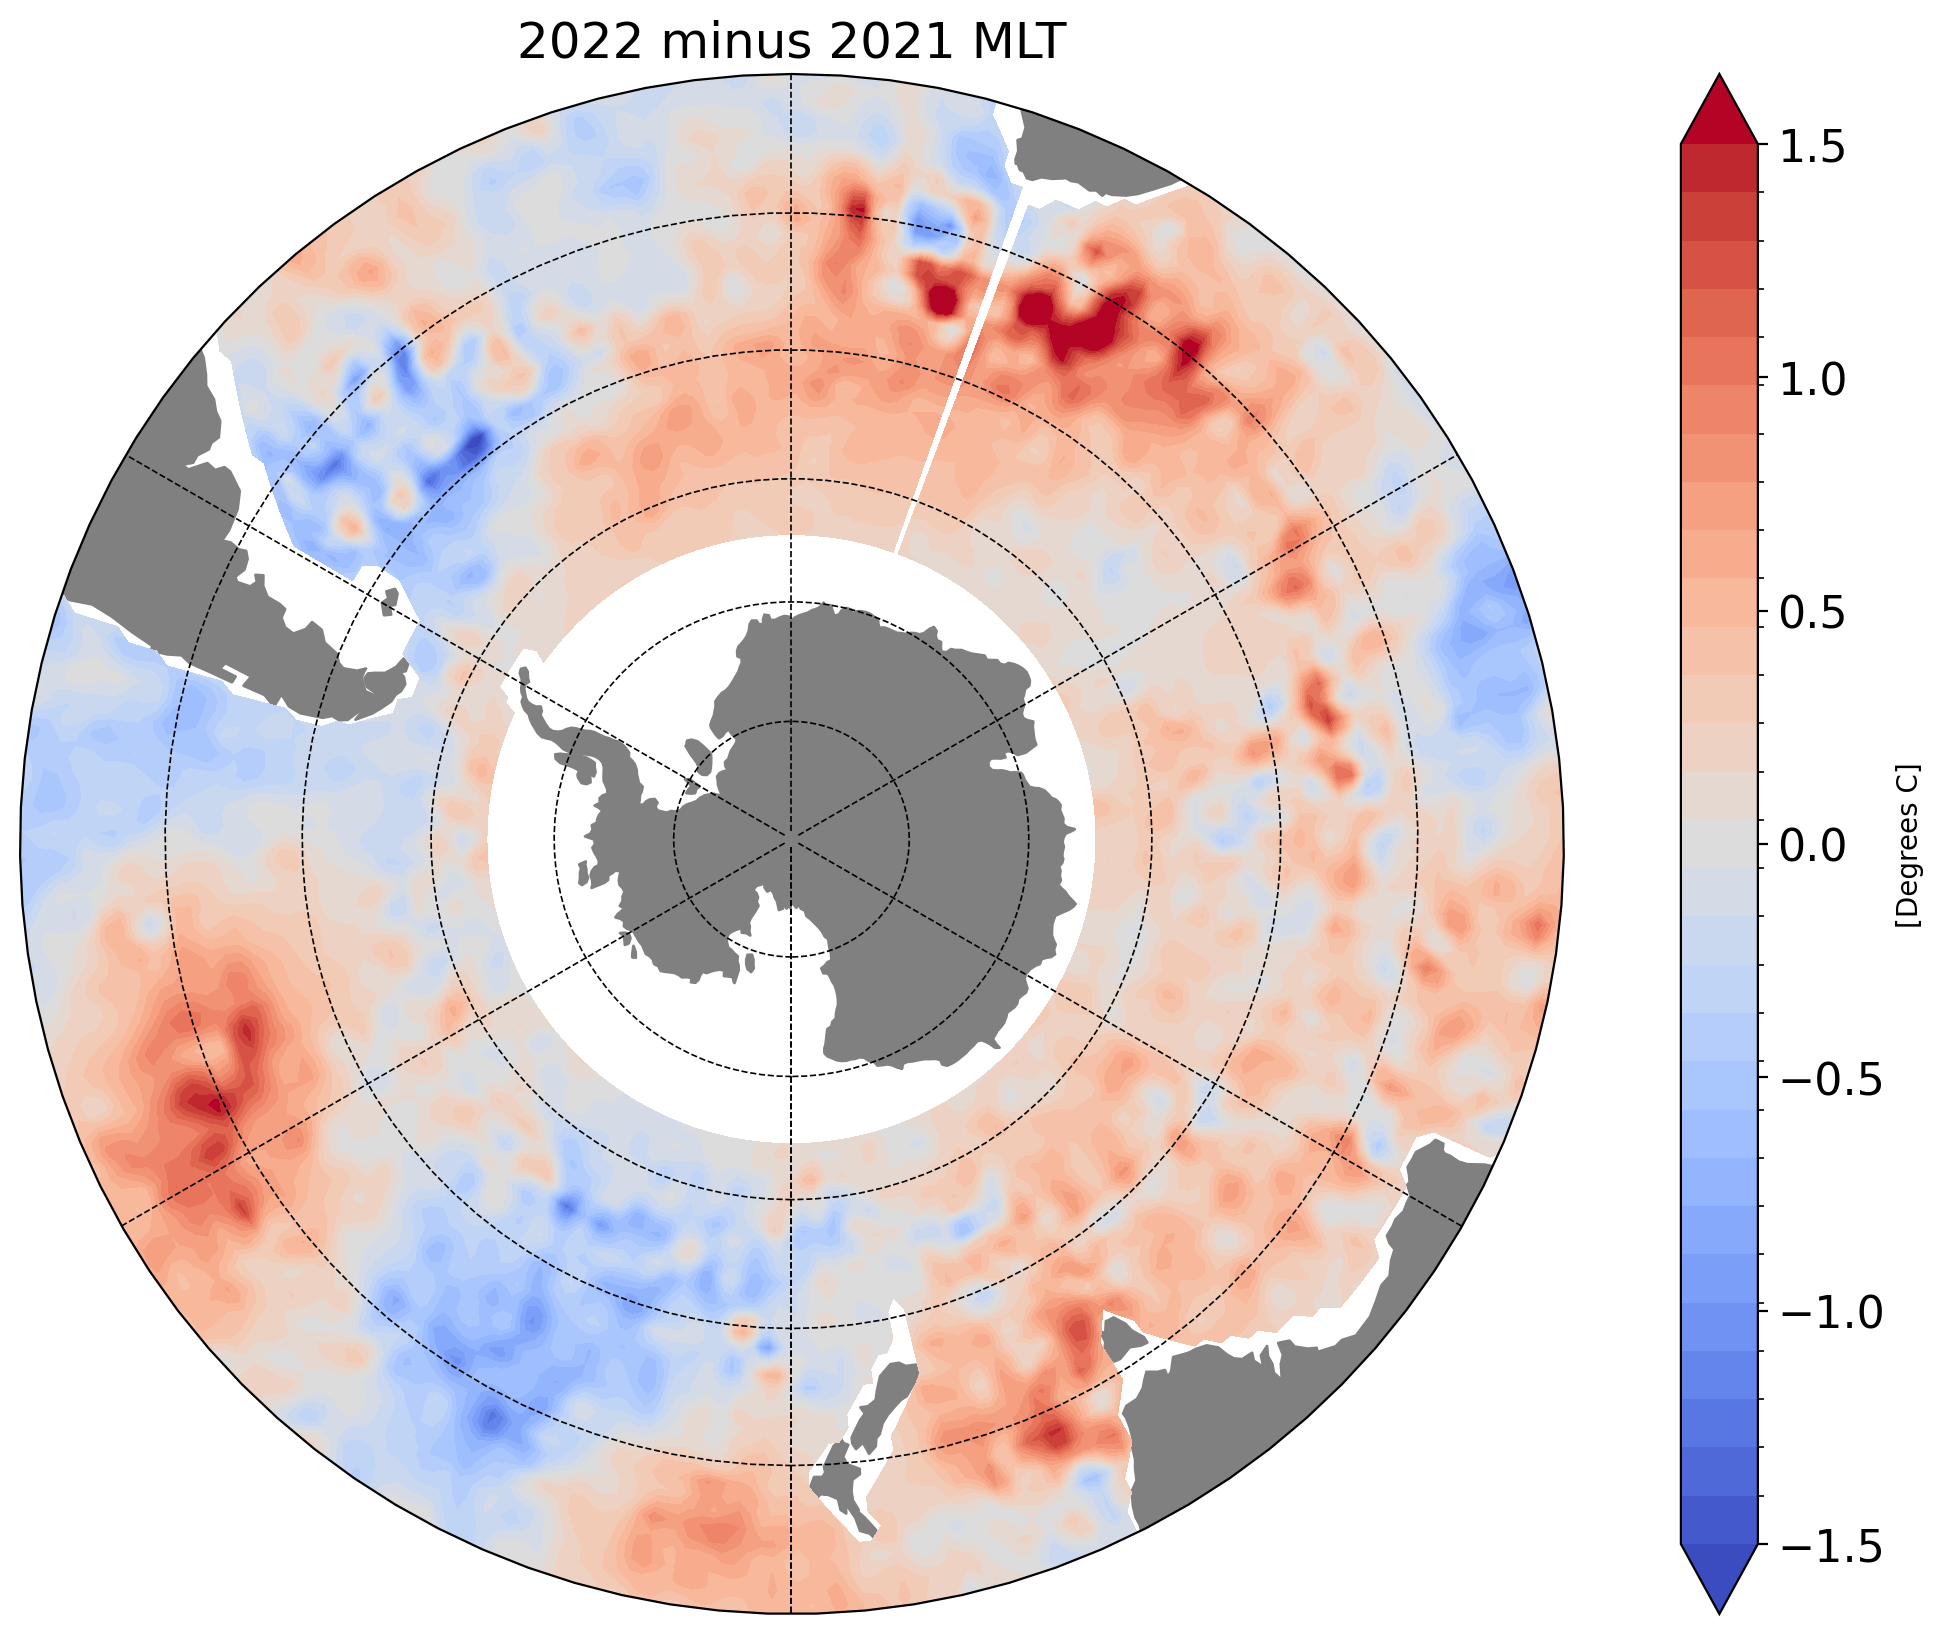

In [47]:
import cartopy.crs as ccrs
import cartopy

plt.figure(figsize=[12,8])

projection=ccrs.SouthPolarStereo()
ax = plt.axes(projection=projection)
ax.set_extent([-180,180,-90,-30], ccrs.PlateCarree())
ax.set_boundary(circle,transform=ax.transAxes)

MLT_levels = np.linspace(-1.5,1.5,30)

p = MLT_2022_minus_2021.plot.contourf(
                        cmap='coolwarm',
                        transform=ccrs.PlateCarree(),
                        levels=MLT_levels,add_colorbar=False,extend='both')

ax.gridlines(linewidth = 0.6, color = 'k', linestyle = '--')
ax.add_feature(cartopy.feature.LAND, color='grey')
cb = plt.colorbar(p, ticks=[-1.5,-1.0,-0.5,0,0.5,1.0,1.5],
                  extend='both',
                  
                  )

cb.ax.tick_params(labelsize=16)
plt.tight_layout()
cb.set_label('[Degrees C]')
plt.title('2022 minus 2021 MLT',fontsize=18)

### Mixed Layer Depth, find depth (~pressure) value of deepest layer that is not a NaN in our mixed layer mask

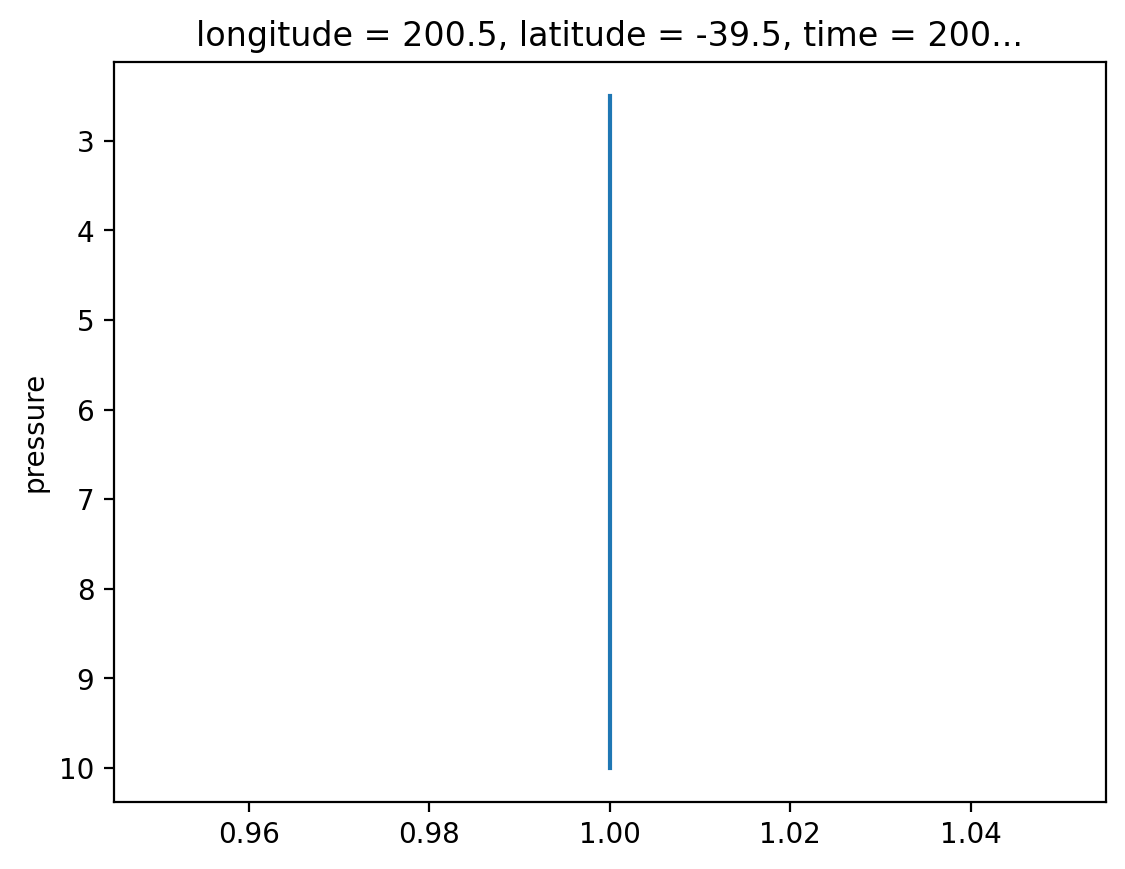

In [36]:
mixed_layer_mask.isel(time=0).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').plot(y='pressure',yincrease=False)

In [37]:
pressure_levels_in_mixed_layer = mixed_layer_mask*mixed_layer_mask.pressure
pressure_max_ml = pressure_levels_in_mixed_layer.max(dim='pressure', skipna=True)

In [38]:
mld = pressure_max_ml

array(10., dtype=float32)

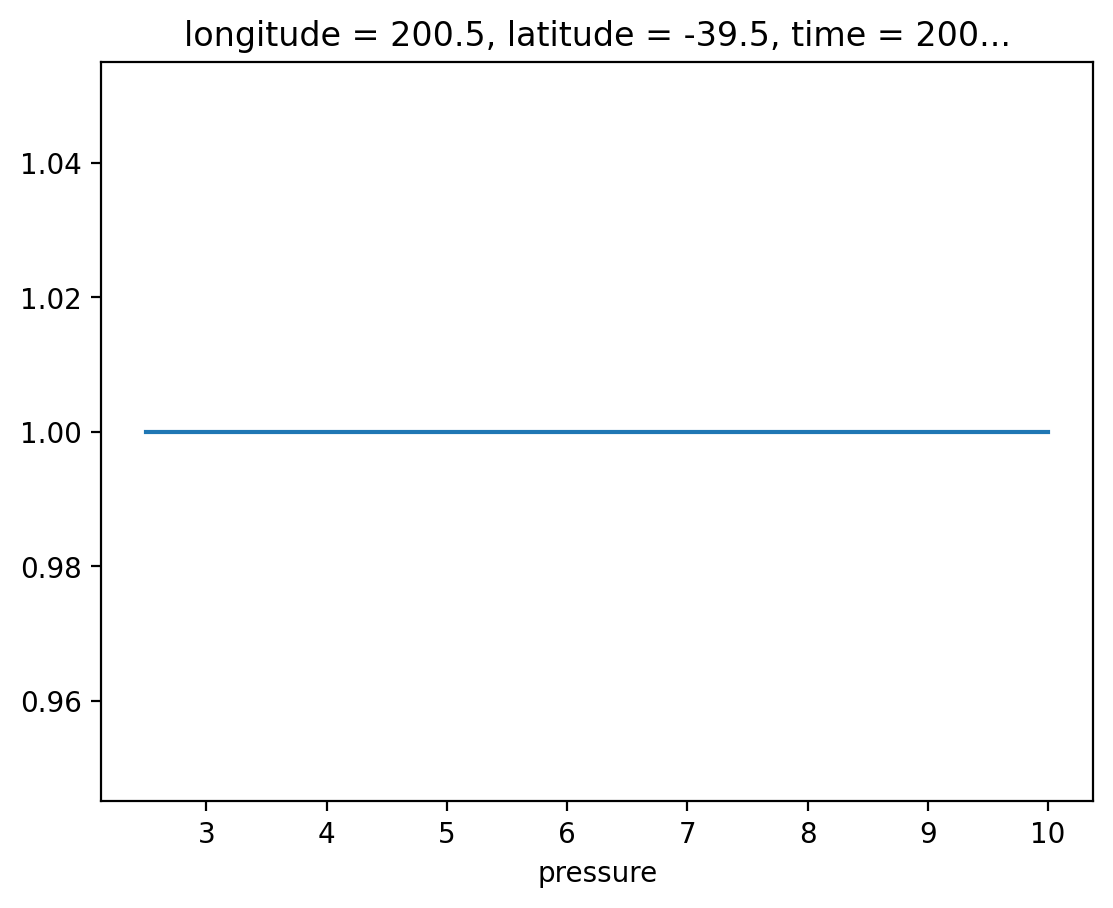

In [39]:
mixed_layer_mask.isel(time=10).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').plot()
mld.isel(time=10).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').values

In [40]:
#### BAMS 2021 Anomalies

MLD_2004_2020 = mld.sel(time=slice('2004-01-31','2020-12-31')).mean(dim='time')
MLD_2021 = mld.sel(time=slice('2021-01-31','2021-12-31')).mean(dim='time')
MLD_2021_report_diff = MLD_2021 - MLD_2004_2020

#### BAMS 2022 Anomalies
MLD_2004_2021 = mld.sel(time=slice('2004-01-31','2021-12-31')).mean(dim='time')
MLD_2022 = mld.sel(time=slice('2022-01-31','2022-10-31')).mean(dim='time')
MLD_2022_report_diff = MLD_2022 - MLD_2004_2021

#### Compute 2022 - 2021:
MLD_2022_minus_2021 = MLD_2022 - MLD_2021

Text(0.5, 1.0, '2021 MLD Anomalies')

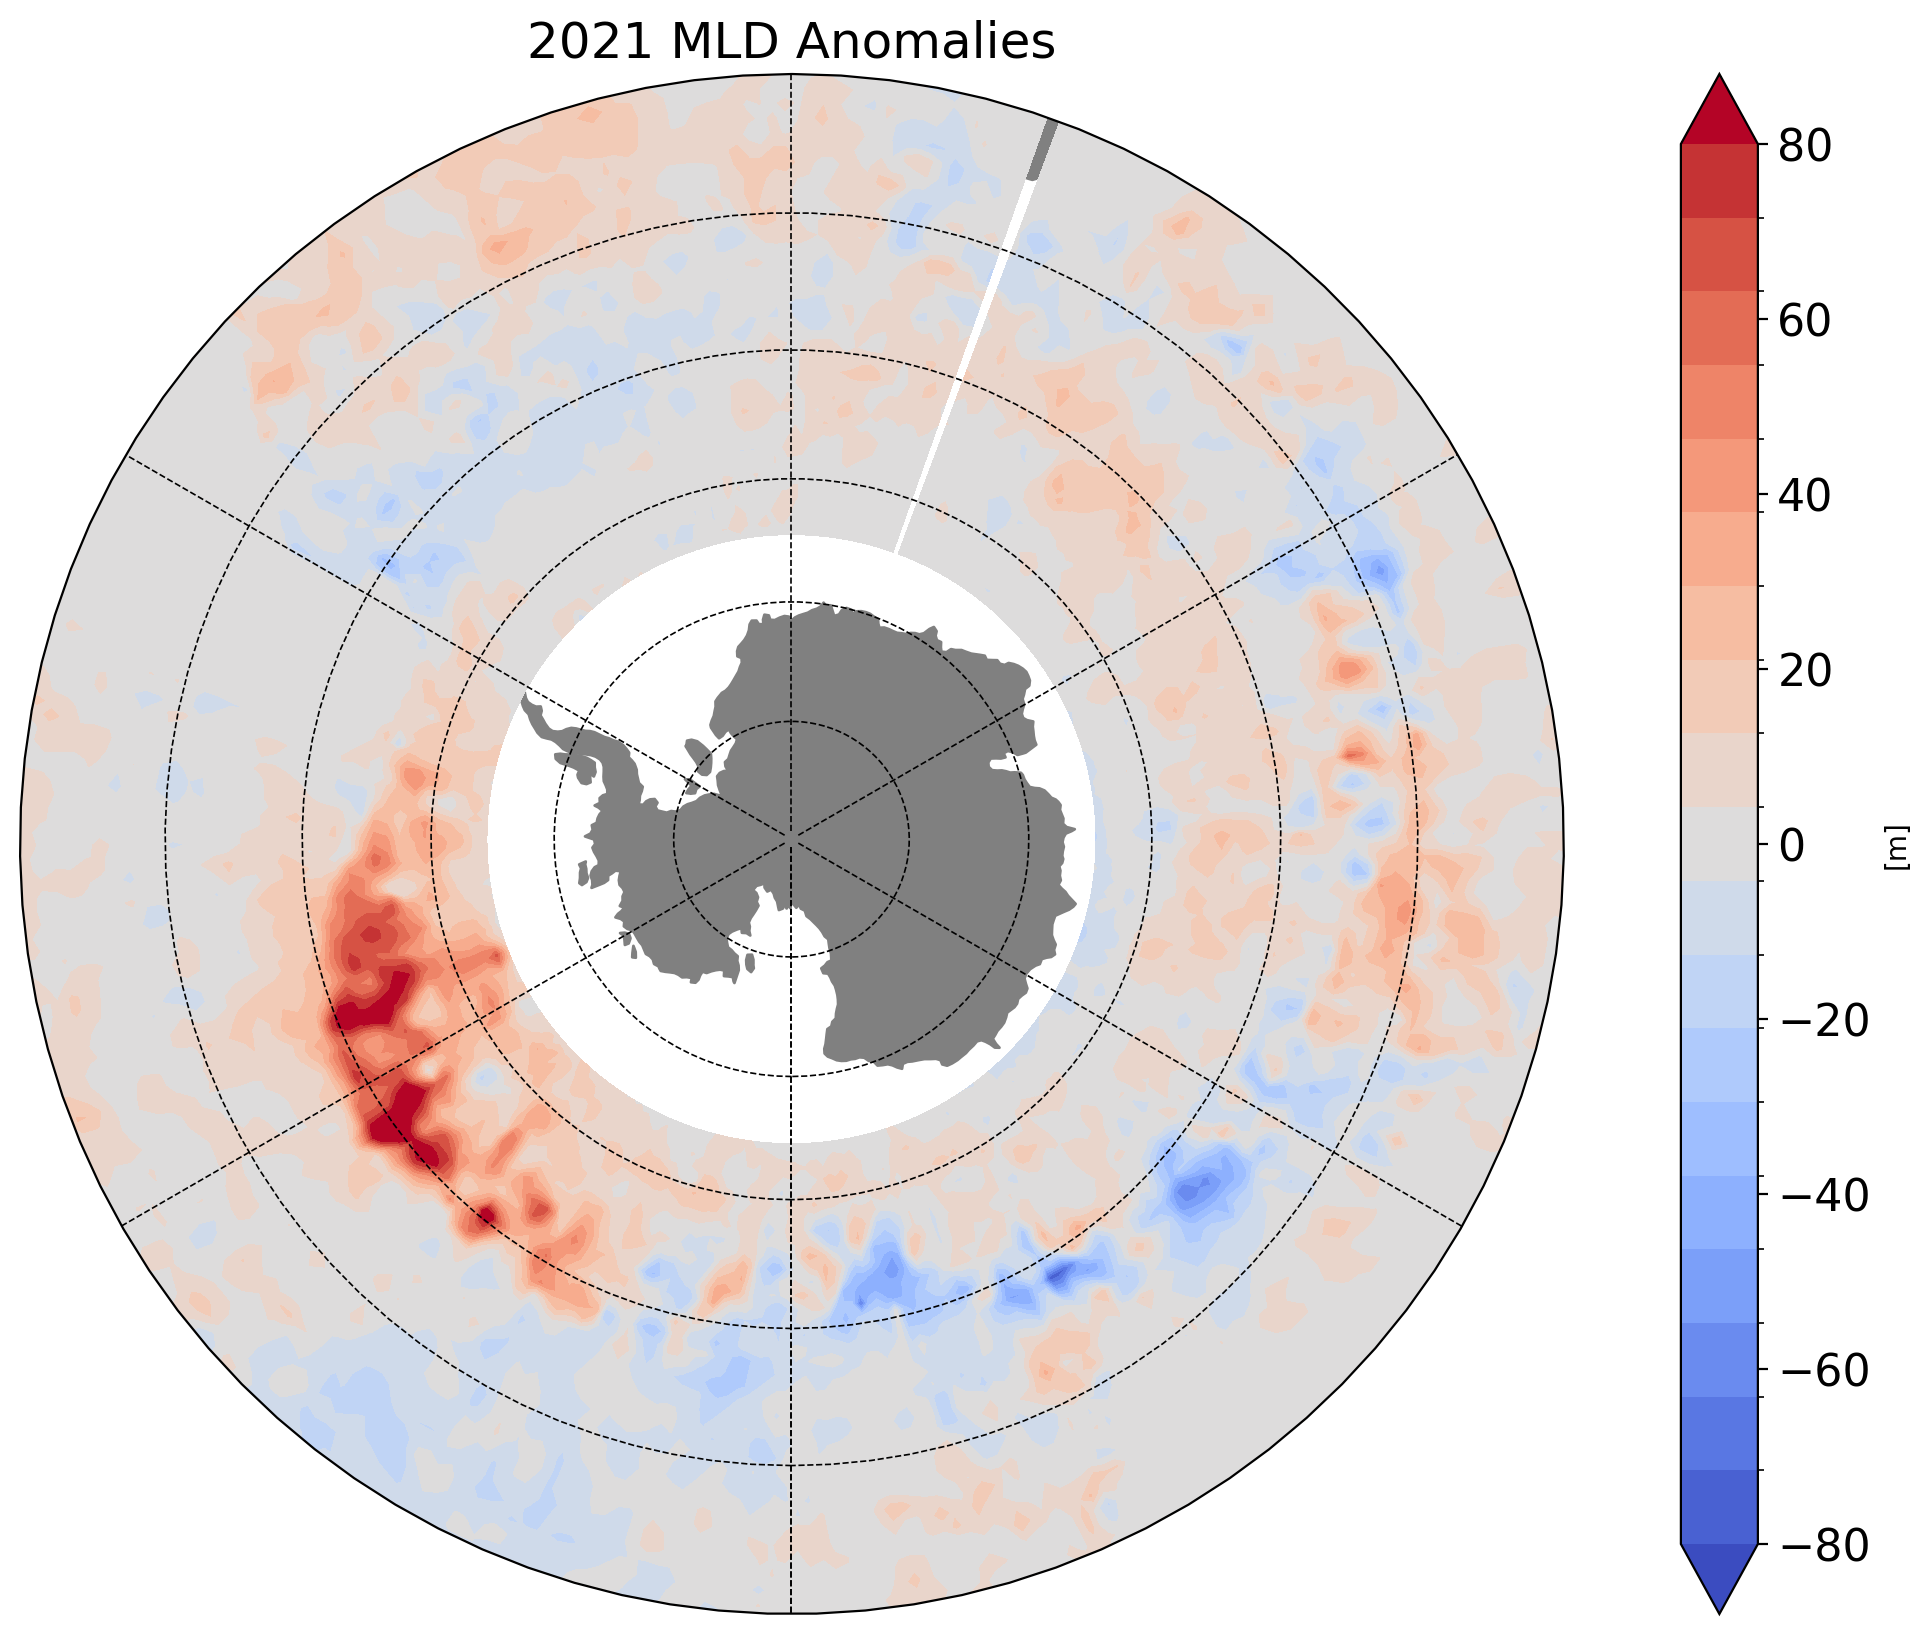

In [41]:
plt.figure(figsize=[12,8])

projection=ccrs.SouthPolarStereo()
ax = plt.axes(projection=projection)
ax.set_extent([-180,180,-90,-30], ccrs.PlateCarree())
ax.set_boundary(circle,transform=ax.transAxes)

MLD_levels = np.linspace(-80,80,20)

p = MLD_2021_report_diff.plot.contourf(
                        cmap='coolwarm',
                        transform=ccrs.PlateCarree(),
                        extend='both',levels=MLD_levels,add_colorbar=False)

ax.gridlines(linewidth = 0.6, color = 'k', linestyle = '--')
ax.add_feature(cartopy.feature.LAND, color='grey')
cb = plt.colorbar(p, ticks=[-80,-60,-40,-20,0,20,40,60,80],
                  extend='both',
                  
                  )

cb.ax.tick_params(labelsize=16)
plt.tight_layout()
cb.set_label('[m]')
plt.title('2021 MLD Anomalies',fontsize=18)

Text(0.5, 1.0, '2022 MLD Anomalies')

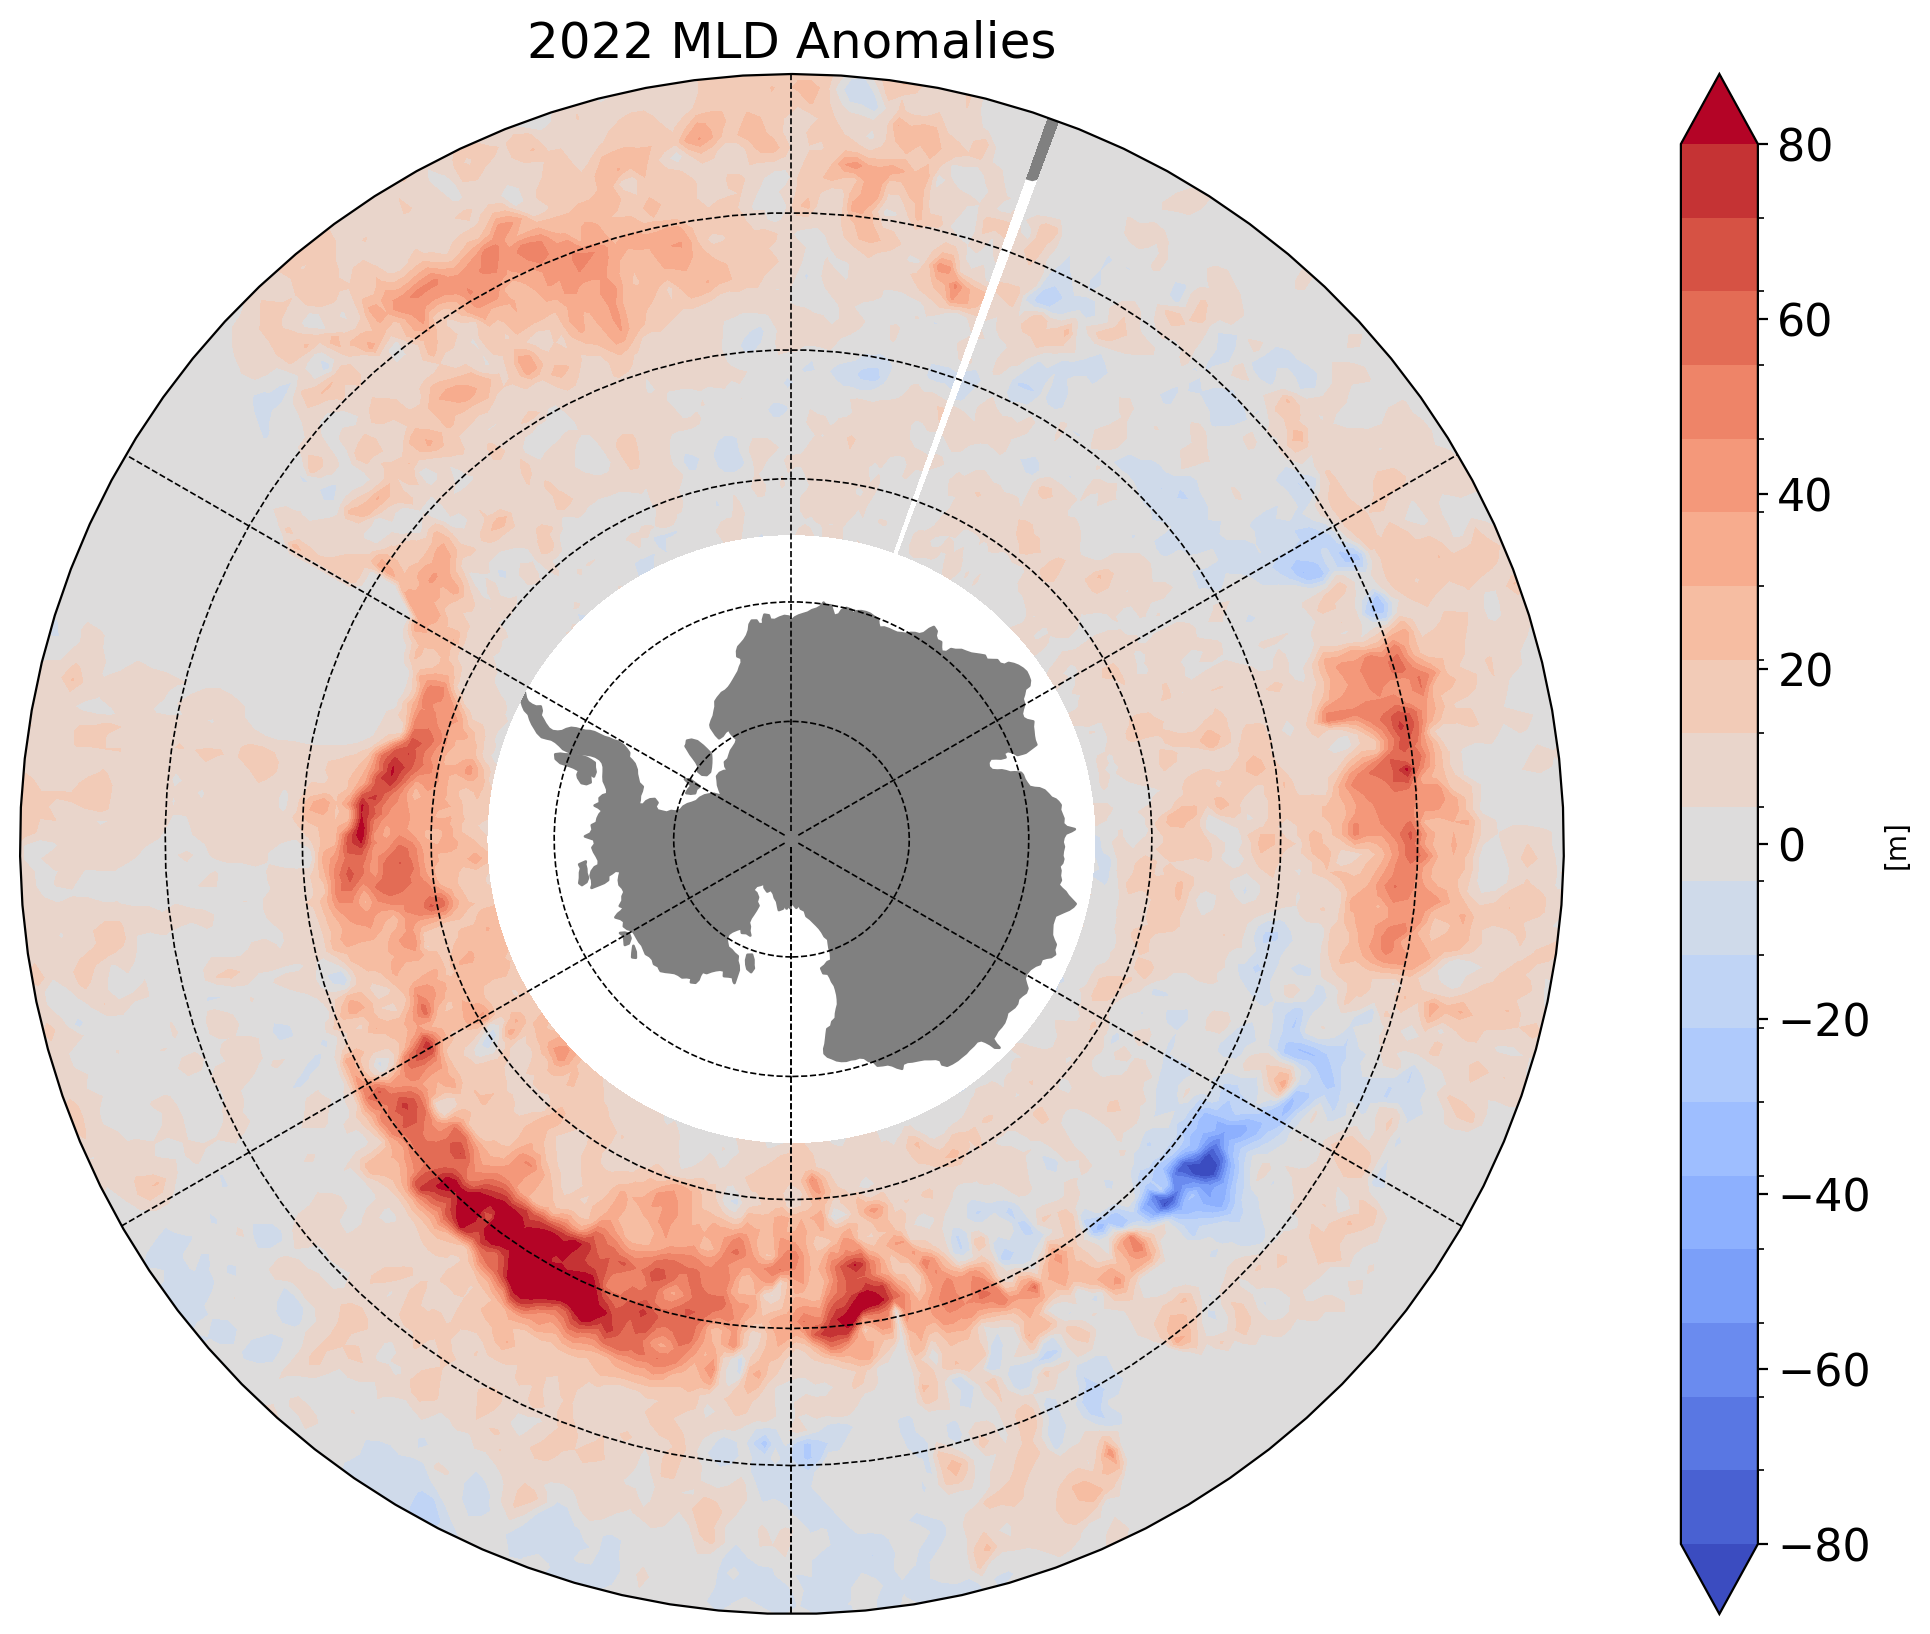

In [42]:
plt.figure(figsize=[12,8])

projection=ccrs.SouthPolarStereo()
ax = plt.axes(projection=projection)
ax.set_extent([-180,180,-90,-30], ccrs.PlateCarree())
ax.set_boundary(circle,transform=ax.transAxes)

MLD_levels = np.linspace(-80,80,20)

p = MLD_2022_report_diff.plot.contourf(
                        cmap='coolwarm',
                        transform=ccrs.PlateCarree(),
                        extend='both',levels=MLD_levels,add_colorbar=False)

ax.gridlines(linewidth = 0.6, color = 'k', linestyle = '--')
ax.add_feature(cartopy.feature.LAND, color='grey')
cb = plt.colorbar(p, ticks=[-80,-60,-40,-20,0,20,40,60,80],
                  extend='both',
                  
                  )

cb.ax.tick_params(labelsize=16)
plt.tight_layout()
cb.set_label('[m]')
plt.title('2022 MLD Anomalies',fontsize=18)

Text(0.5, 1.0, '2022 minus 2021 MLD ')

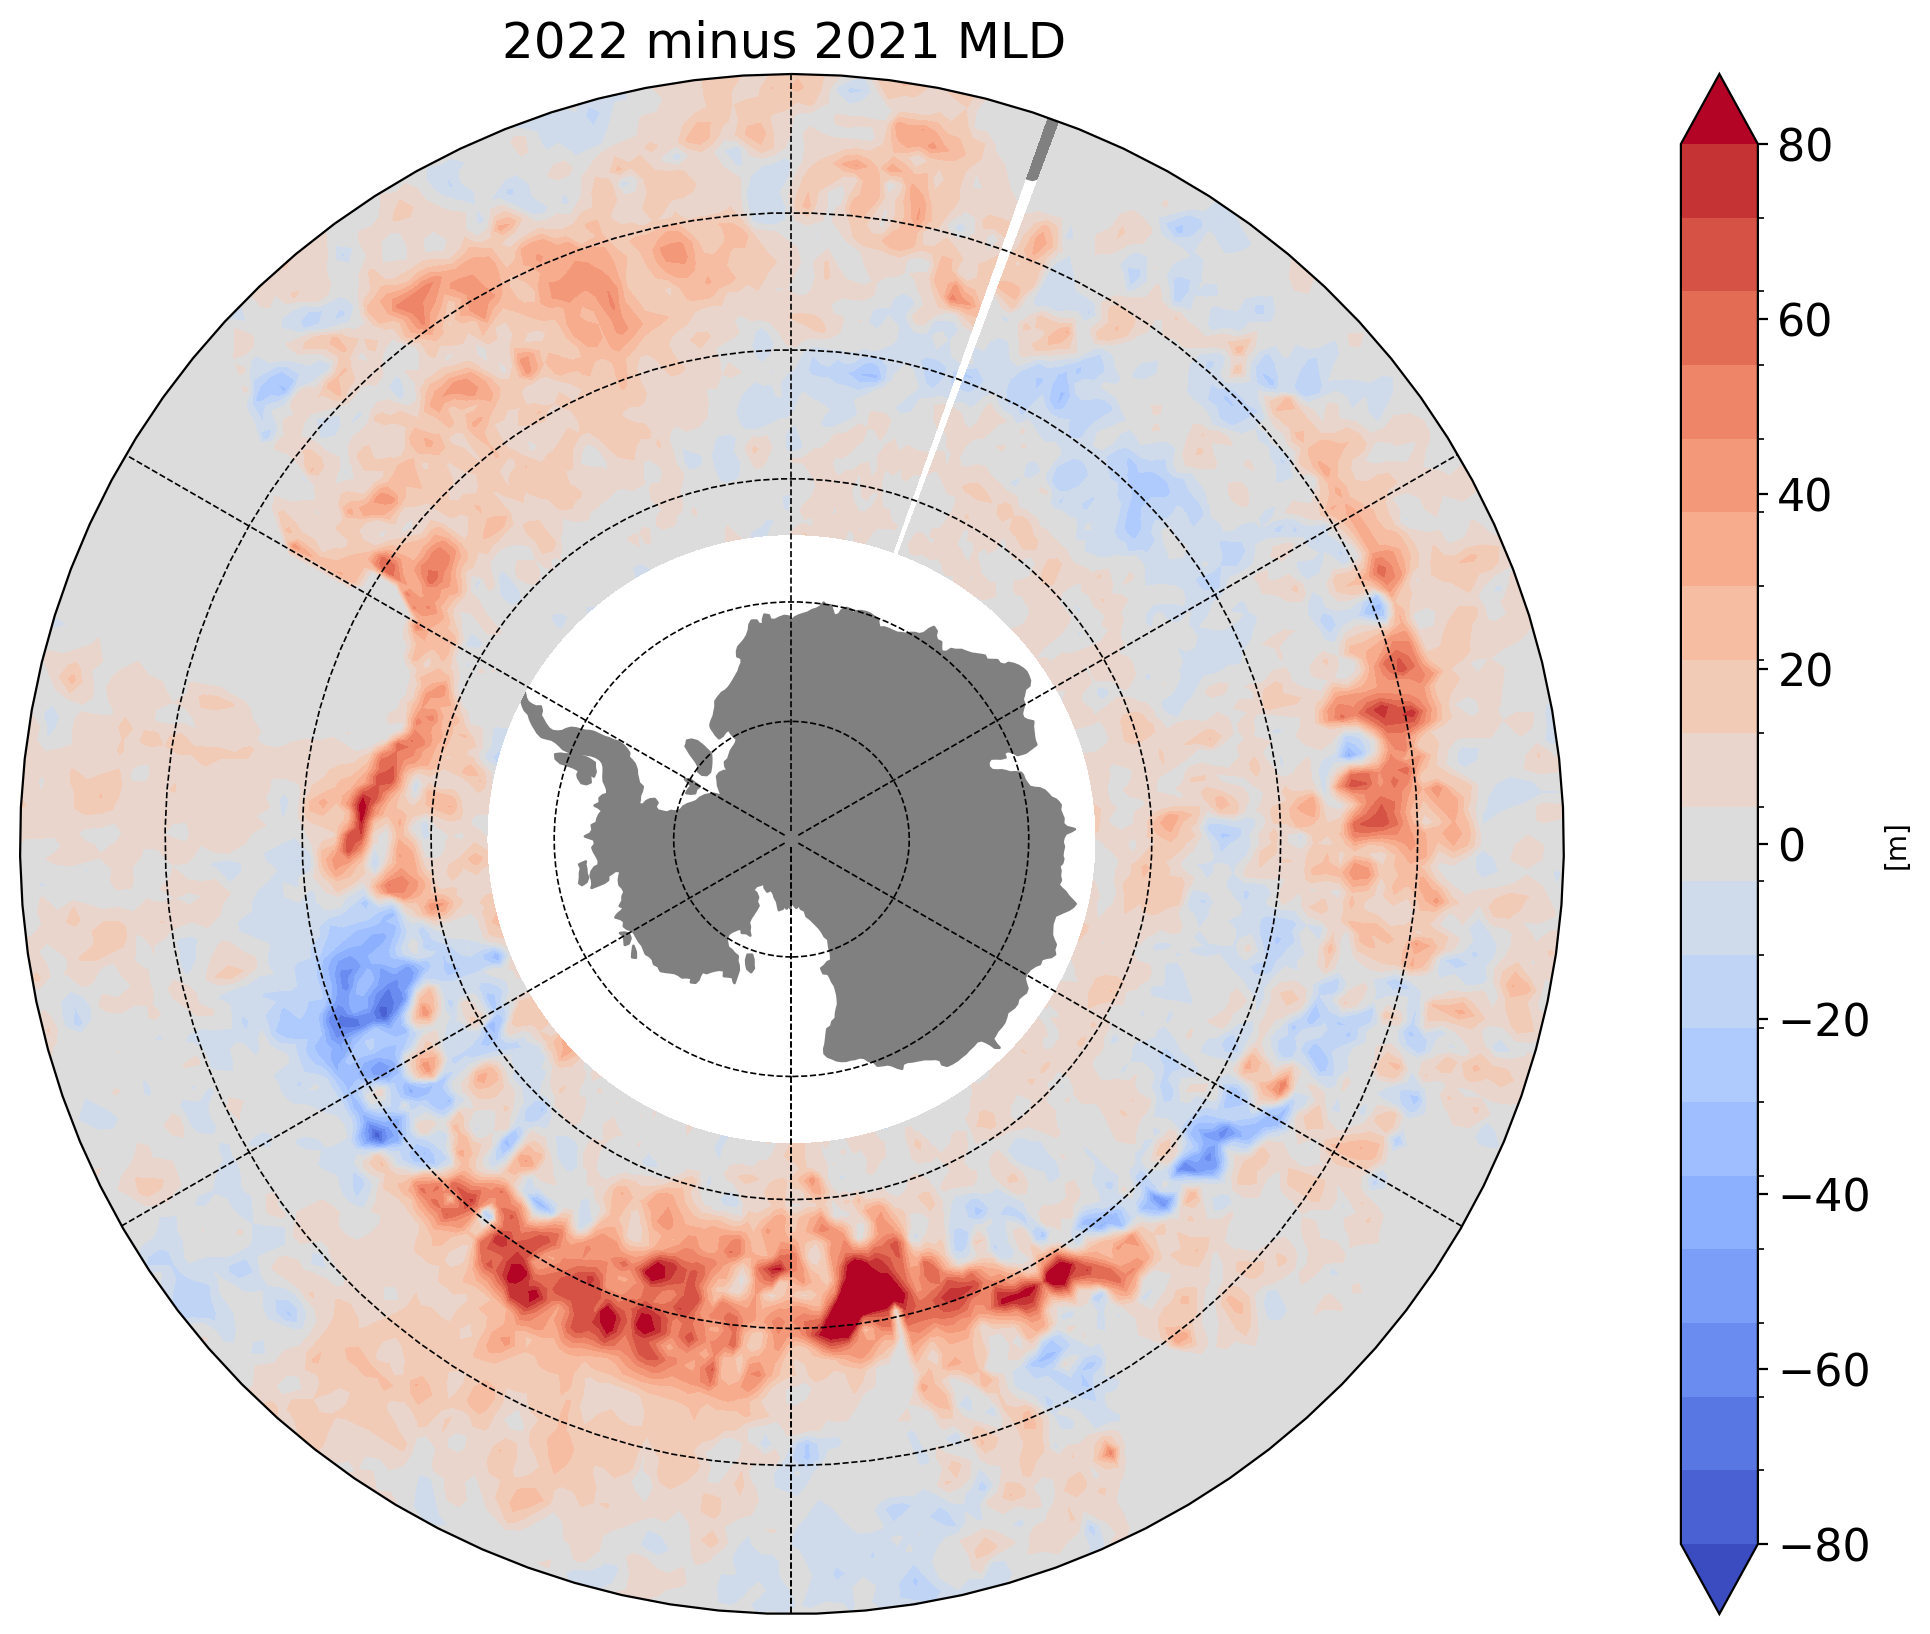

In [43]:
plt.figure(figsize=[12,8])

projection=ccrs.SouthPolarStereo()
ax = plt.axes(projection=projection)
ax.set_extent([-180,180,-90,-30], ccrs.PlateCarree())
ax.set_boundary(circle,transform=ax.transAxes)

MLD_levels = np.linspace(-80,80,20)

p = MLD_2022_minus_2021.plot.contourf(
                        cmap='coolwarm',
                        transform=ccrs.PlateCarree(),
                        extend='both',levels=MLD_levels,add_colorbar=False)

ax.gridlines(linewidth = 0.6, color = 'k', linestyle = '--')
ax.add_feature(cartopy.feature.LAND, color='grey')
cb = plt.colorbar(p, ticks=[-80,-60,-40,-20,0,20,40,60,80],
                  extend='both',
                  
                  )

cb.ax.tick_params(labelsize=16)
plt.tight_layout()
cb.set_label('[m]')
plt.title('2022 minus 2021 MLD ',fontsize=18)

In [44]:
mld = mixed_layer_mask.idxmin(dim='pressure', skipna=True)

In [45]:
mld.isel(time=0).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest')

<xarray.DataArray 'pressure' ()>
array(2.5, dtype=float32)
Coordinates:
    longitude  float32 200.5
    latitude   float32 -39.5
    time       datetime64[ns] 2004-01-31

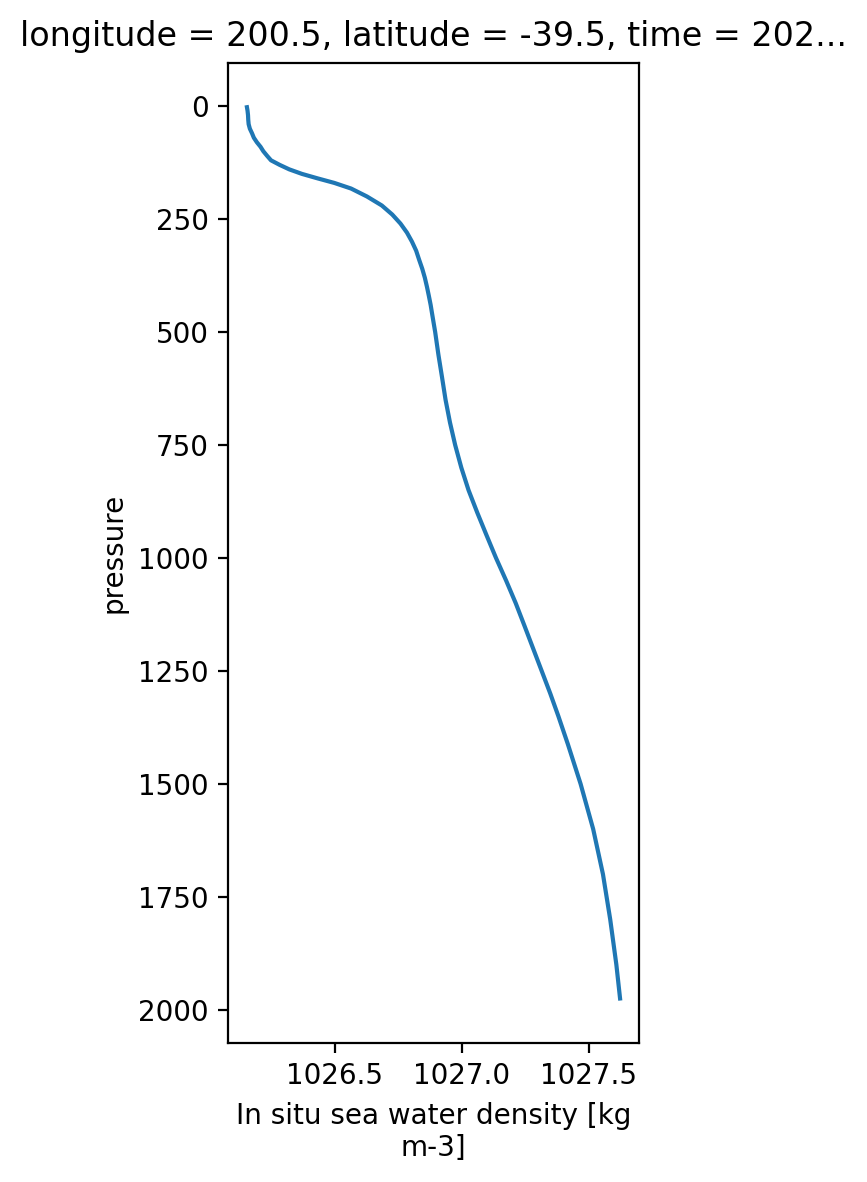

In [46]:
## Plot a profile of potential density
plt.figure(figsize=(3,6))
potential_density_ts.isel(time=200).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').plot(y='pressure',
                                                                                                              yincrease=False)

plt.tight_layout()                                                                                             

In [48]:
plt.figure(figsize=(3,6))
drho_relative_to_surface.isel(time=0).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').plot(y='pressure',
                                                                                                                    yincrease=False,
                                                                                                                   color='k',
                                                                                                                   linewidth=2)
mld.isel(time=0).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').plot(y='pressure', yincrease=False,
                                                                                              color='red',
                                                                                              linewidth=2)



drho_relative_to_surface.isel(time=1).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').plot(y='pressure',
                                                                                                                    yincrease=False,
                                                                                                                   color='k',
                                                                                                                   linewidth=2)
mld.isel(time=1).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').plot(y='pressure', yincrease=False,
                                                                                              color='red',
                                                                                              linewidth=2)

drho_relative_to_surface.isel(time=2).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').plot(y='pressure',
                                                                                                                    yincrease=False,
                                                                                                                   color='k',
                                                                                                                   linewidth=2)
mld.isel(time=2).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').plot(y='pressure', yincrease=False,
                                                                                              color='red',
                                                                                              linewidth=2)

drho_relative_to_surface.isel(time=3).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').plot(y='pressure',
                                                                                                                    yincrease=False,
                                                                                                                   color='k',
                                                                                                                   linewidth=2)
mld.isel(time=3).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').plot(y='pressure', yincrease=False,
                                                                                              color='red',
                                                                                              linewidth=2)

(array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 array([2.        , 2.0999999 , 2.20000005, 2.29999995, 2.4000001 ,
        2.5       , 2.5999999 , 2.70000005, 2.79999995, 2.9000001 ,
        3.        ]),
 <BarContainer object of 10 artists>)

Error in callback <function _draw_all_if_interactive at 0x724c459e6c10> (for post_execute):


ConversionError: Failed to convert value(s) to axis units: 'pressure'

ConversionError: Failed to convert value(s) to axis units: 'pressure'

<Figure size 300x600 with 1 Axes>

array([0.        , 0.00231934, 0.00427246, 0.00512695, 0.00671387,
       0.01159668, 0.02001953, 0.02734375, 0.0390625 , 0.0534668 ,
       0.06481934, 0.07946777, 0.09484863, 0.12866211, 0.16674805,
       0.21655273, 0.27868652, 0.3441162 , 0.4104004 , 0.47277832,
       0.5316162 , 0.5727539 , 0.60498047, 0.63049316, 0.65026855,
       0.666626  , 0.67858887, 0.6907959 , 0.7011719 , 0.70947266,
       0.71691895, 0.723999  , 0.73046875, 0.7418213 , 0.7545166 ,
       0.7687988 , 0.7828369 , 0.8001709 , 0.8206787 , 0.8449707 ,
       0.87353516, 0.90808105, 0.9445801 , 0.98168945, 1.0214844 ,
       1.0594482 , 1.0938721 , 1.1278076 , 1.1616211 , 1.1954346 ,
       1.2272949 , 1.2651367 , 1.3150635 , 1.3647461 , 1.4034424 ,
       1.4318848 , 1.4561768 , 1.4709473 ], dtype=float32)

In [49]:
drho_relative_to_surface.isel(time=100).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest').values

array([ 0.0000000e+00,  0.0000000e+00,  3.6621094e-04,  9.7656250e-04,
       -1.3427734e-03, -4.7607422e-03, -9.3994141e-03,  2.2338867e-02,
        2.0080566e-01,  3.8562012e-01,  5.2490234e-01,  6.0632324e-01,
        6.6943359e-01,  7.2460938e-01,  7.7319336e-01,  8.1652832e-01,
        8.5534668e-01,  8.9465332e-01,  9.4079590e-01,  9.9938965e-01,
        1.0631104e+00,  1.1188965e+00,  1.1651611e+00,  1.2017822e+00,
        1.2312012e+00,  1.2535400e+00,  1.2707520e+00,  1.2860107e+00,
        1.2994385e+00,  1.3095703e+00,  1.3200684e+00,  1.3297119e+00,
        1.3388672e+00,  1.3527832e+00,  1.3703613e+00,  1.3858643e+00,
        1.3992920e+00,  1.4146729e+00,  1.4321289e+00,  1.4536133e+00,
        1.4779053e+00,  1.5070801e+00,  1.5397949e+00,  1.5731201e+00,
        1.6114502e+00,  1.6478271e+00,  1.6829834e+00,  1.7161865e+00,
        1.7512207e+00,  1.7844238e+00,  1.8164062e+00,  1.8574219e+00,
        1.9129639e+00,  1.9614258e+00,  2.0004883e+00,  2.0317383e+00,
      

In [50]:
mld = drho_relative_to_surface.where(drho_relative_to_surface<0.03)

In [51]:
mld.isel(time=200).sel(latitude=-40,method='nearest').sel(longitude=200,method='nearest')

<xarray.DataArray (pressure: 58)>
array([-0.00231934,  0.        ,  0.00195312,  0.00280762,  0.00439453,
        0.00915527,  0.01757812,  0.02490234,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan], dtype=float32)
Coordinates:
    longitude  float32 200.5
    latitude   float32 -39.5
  * pressure   (pressure) float32 2.5 10.0 20.0 ... 1.8e+03 1.9e+03 1.975e+03
    time       datetime64[ns] 2020-09-30